# Manuscript figures

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import seaborn as sns
import matplotlib.pyplot as plt
import pooch
import pandas as pd
from tqdm import tqdm
import numpy as np

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp
import src.analysis.distributions as db
import src.analysis.attributions as ab
import src.colabfold.colabfold as cf
import src.benchmark.clinvar as bcv

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Figure 1

### Figure 1A

![](fig/fig1a.png)

### Figure 1B

In [9]:
tx_ids_1kg = hs.list_haplotypes(cache = hs.DIR_DICT["haplotypes"])
tx_ids_hgdp = hs.list_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"])
print("tx_id union",len(set(tx_ids_1kg).union(tx_ids_hgdp)))
print("tx_id intersection",len(set(tx_ids_1kg).intersection(tx_ids_hgdp)))

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'
Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'
tx_id union 92863
tx_id intersection 39986


Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [10]:
proteins_df = pg.merge_resources(rows_per_id=None)

haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "union",
                                         use_deepcopy = True) 

ProteinGym: Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/2503 [00:00<?, ?it/s]

Using deepcopy
Merging 2847 tx_ids using union


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Merged 132721 haplotypes across 2847 tx_ids.


Plot the number of haplotypes per protein, as well as the number of WT variants per haplotype.

Adding reference haplotype:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to dataframe:   0%|          | 0/2847 [00:00<?, ?it/s]

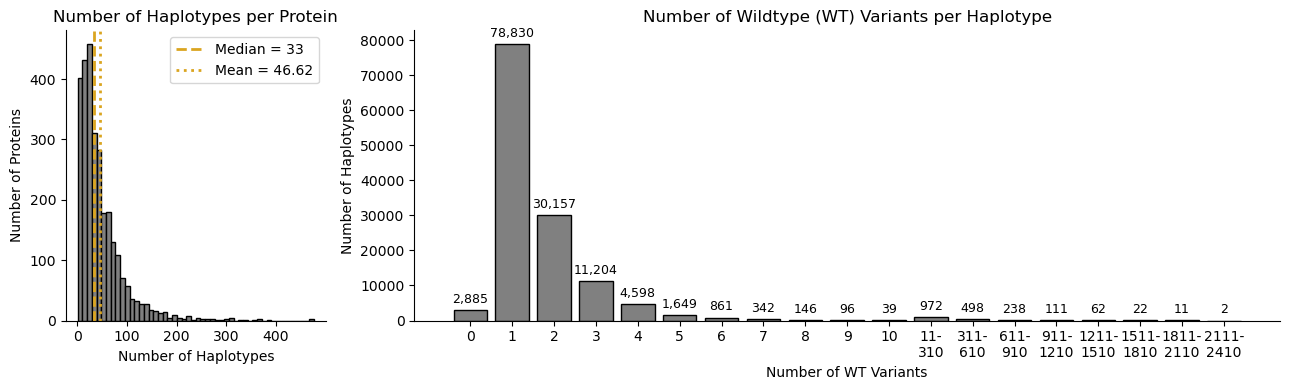

In [ ]:
fig1b = hs.plot_haplotypes_summary(haplotypes, 
                                   show_median=True,
                                   show_mean=False,
                                   save_path="manuscript/fig/fig1b.png")

### Figure 1C

Map haplotypes back to samples (individuals).

In [ ]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 2847


Processing sample to haplotype name maps:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to DataFrame


In [ ]:
freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
) 
freq_df.head()

NameError: name 'haps_to_samples' is not defined

In [203]:
fig1c = hs.plot_haplotypes_and_superpop_bar(freq_df,
                                            haplotypes,
                                            show=False,
                                            width_ratios=(.2,1), figsize=(13,5))

fig = fig1c["subplot1"]["fig"]  
# If the figure was already shown or closed, it may be blank when saving.
# To ensure the image is not blank, explicitly draw the canvas before saving.
fig.canvas.draw_idle() 
fig.savefig("manuscript/fig/fig1c_left.png", **utils.FIG_SAVE_KWARGS)

fig = fig1c["subplot2"]["fig"]
fig.plot() # Upset plot has a slightly different structure
fig.plot().savefig("manuscript/fig/fig1c_right.png", **utils.FIG_SAVE_KWARGS)

NameError: name 'freq_df' is not defined

### Figure 1D

In [6]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

  0%|          | 0/2525 [00:00<?, ?it/s]

Extracting ID columns.
Using default maps.
Simplifying annotations.
      ClinSig  Count       Source Consequence    Consequence (Source)
0      benign   2615  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
1  pathogenic   3327  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
0      benign  11718      ClinVar         UTR           UTR (ClinVar)
1  pathogenic   2053      ClinVar         UTR           UTR (ClinVar)
0      benign  30727   ProteinGym    Missense   Missense (ProteinGym)
1  pathogenic  32000   ProteinGym    Missense   Missense (ProteinGym)


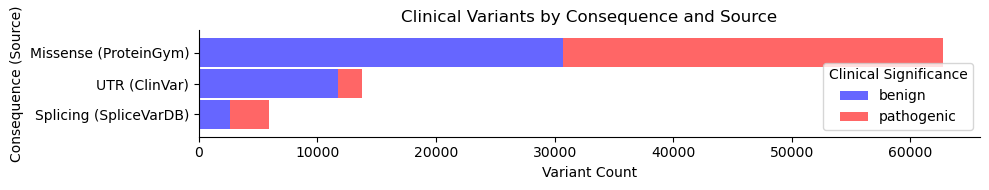

In [32]:
fig1d = va.variant_count_by_source_barplot(show_plot=True)
fig1d["fig"].savefig("manuscript/fig/fig1d.png", **utils.FIG_SAVE_KWARGS)

### Figure 1E

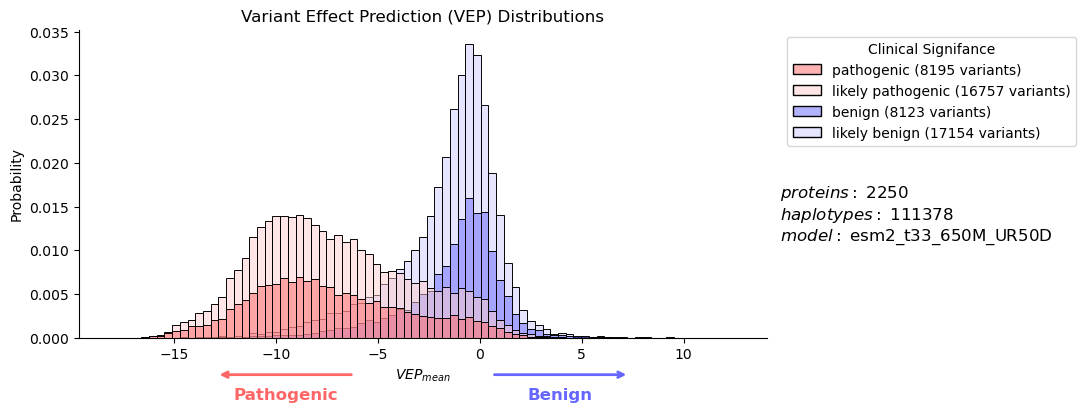

In [33]:
fig1e = db.plot_vep_histogram_with_arrows(vep_df, 
                                          model_name=model_name,  
                                          arrow_y= -0.35,
                                          arrow_head_length=0.047,
                                          arrow_length=.19,
                                          figsize=(11, 4),
                                          arrow_text_fontsize=9,
                                          external_legend_annotation=True)
fig1e["fig"].savefig("manuscript/fig/fig1e.png", **utils.FIG_SAVE_KWARGS)

### Figure 1F

/home/schilder/projects/VEP_protein/src/analysis/distributions.py:1032: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stacked = data.groupby(['VEP_binned_label', 'VEP_percentile_decile']).size().unstack(fill_value=0)
/home/schilder/projects/VEP_protein/src/analysis/distributions.py:1203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


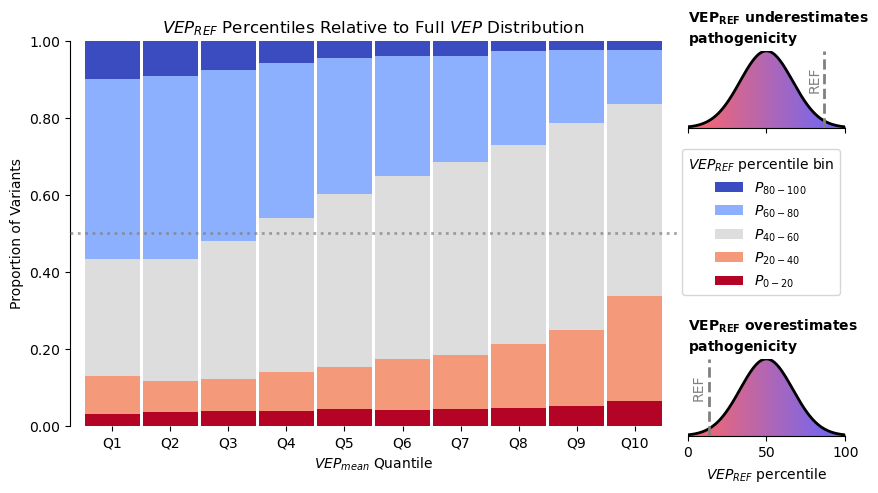

In [34]:
#### Percentile barplot version #### 
fig1f_pct = db.plot_ref_vep_percentile_stacked_bar(vep_df,
                                                    figsize=(10, 5), 
                                                    barplot_width_ratio=5, 
                                                    n_ref_pct_bins=5,
                                                    legend_on_right=True,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,   
                                                    schematic_width_ratio=1.3,
                                                    schematic_padding_left = -0.15,
                                                    schematic_padding_top=0.02,
                                                    schematic_heights=[0.2, 0.6, 0.2]
                                                    )
fig1f_pct["fig"].savefig("manuscript/fig/fig1f.png", **utils.FIG_SAVE_KWARGS)   
 

## Figure 2

In [ ]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":"ENST00000370192"}
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2'}

# Get specific instance of the protein
target_gene = "BRCA1" # DYPD
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

In [3]:

#### Import directly from AlphaFoldDB ####
# structure = cf.import_mmcif(protein_id = uniprot_id)[0]
# contact_map = cf.get_contact_map(structure, 
#                                  max_distance=8.0, 
#                                  continuous=True, 
#                                  return_distance_map=True )


#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1,
                            ref_only = True) 

contact_map_ref = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True,
                                        as_dict=False)  


contact_map_dist_ref = cf.import_contact_maps(pdb_files,
                                            return_raw_distance_map=True,
                                            as_dict=False)  


1 PDB files found


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  4.84it/s]


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [4]:
contact_map_binary_ref = cf.import_contact_maps(pdb_files,
                                                max_distance=8.0, 
                                                continuous=False, 
                                                return_distance_map=False,
                                                as_dict=False ) 

100%|██████████| 1/1 [00:00<00:00,  4.82it/s]


In [5]:
model_name = "esm2_t33_650M_UR50D"
force = False

if 'vep_files' not in globals() or force:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein']==refseq_id)]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0]  


No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 202449 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 1
scoring_strategy: 3
variant_set: 1
haplotype: 111378
protein: 2250
No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 144 masked-marginals parquet files


Reading files:   0%|          | 0/144 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 2.91GB/s]


VEP dataframe shape: (65664, 73)
n_haplotypes:  144


Use ridge regression to find WT-Clinical variant interactions.

In [9]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(vep_df=vep_prot,
                                                                       alpha=1)  
utils.save_pickle(wtvariants_to_vep_linear_model_out, 
        f"results/data/wtvariants_to_vep_linear_model_out_{target_gene}.pkl")
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]

vep_matrix shape:  (144, 456)
wt_matrix shape:  (144, 132)
Dropped 1 haplotypes due to NaNs in input or target matrices.
Saving ==> results/data/wtvariants_to_vep_linear_model_out_BRCA1.pkl


### Figure 2A

Toy schematic of variant sensitization maps methodology (ridge regression method).

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Found 10x10 submatrix at rows 0-10, cols 121-131 with 20.0% 1s


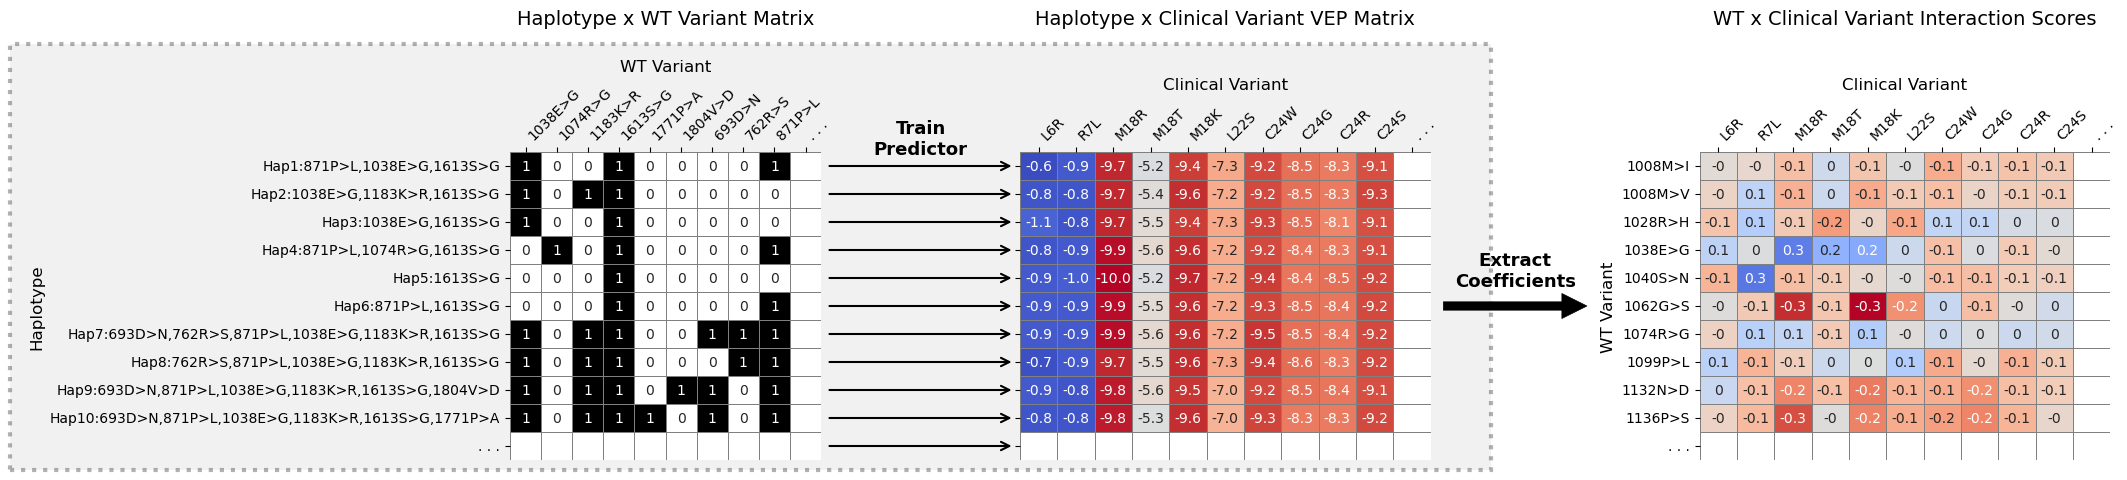

<Figure size 640x480 with 0 Axes>

In [10]:
fig2a = ab.plot_variant_sensitization_schematic(wtvariants_to_vep_linear_model_out,    
                                                n_clinical_variants=10,
                                                n_haplotypes=10,
                                                n_wt_variants=10,
                                                title_y_position=1.2,
                                                include_any_1_col=True, 
                                                include_any_1_row=False,
                                                grey_box_left_extension=0.23, 
                                                grey_box_top_extension=0.25, 
                                                add_grey_box=True,   
                                                rotate_x_labels=True, 
                                                heatmap_aspect=(.9, .75, .75),
                                                replace_haplotype_prefix=True)
fig2a['fig'].savefig("manuscript/fig/fig2a.png", **utils.FIG_SAVE_KWARGS)
fig2a['fig']

### Figure 2B

BRCA1 AlphaFold contact map (reference sequence).

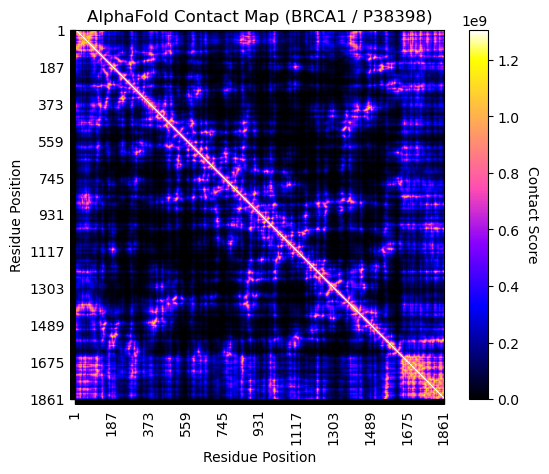

In [11]:
fig2b = cf.plot_contact_map(contact_map=contact_map_ref, 
                            title=f"AlphaFold Contact Map ({target_gene} / {uniprot_id})",  
                            bin_size=1,   
                            pow=4, 
                            agg_func=np.nanmax)
contact_map_ref  = fig2b["data"]["contact_map"]
contact_map_ref_binned = fig2b["data"]["contact_map_binned"]
fig2b['fig'].savefig("manuscript/fig/fig2b.png", **utils.FIG_SAVE_KWARGS)

### Figure 2C

BRCA1 sensitization map (aligned) +  BRCA1 AlphaFold contact map (reference sequence).

Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.  
Then plot the contact map and the sensitization map.

In [12]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 23.31it/s]


Number of top interactions: 518 (0.86% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 58.58x


In [29]:
vep_prot.loc[(vep_prot["site"].isin(top_interactions["site"].head(10)))].groupby("site")["VEP"].mean().sort_values(ascending=False)
# vep_prot.loc[vep_prot["site"]=="NP_009225.1:V1687I"]["VEP"].hist(bins=50)

site
NP_009225.1:Y1853H     0.466824
NP_009225.1:Y179C     -0.623751
NP_009225.1:P1859R    -0.997451
NP_009225.1:V1687I    -2.108766
NP_009225.1:V1653L    -5.326225
NP_009225.1:T1684A    -6.312315
NP_009225.1:S1722F    -9.086795
NP_009225.1:L1839S   -10.287786
NP_009225.1:V1687G   -13.562093
NP_009225.1:Q1721P   -14.548687
Name: VEP, dtype: float64

In [19]:
top_interactions.head(20)

,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT
25444,1729L>Q,NP_009225.1:S1722F,1.132624,1.132624,more benign,1,1.064248,S1722F,1729,L,Q,1722,S,F
24133,1706G>A,NP_009225.1:V1687I,0.651702,-0.651702,more pathogenic,1,0.807280,V1687I,1706,G,A,1687,V,I
24100,1706G>A,NP_009225.1:T1684A,0.503096,0.503096,more benign,1,0.709293,T1684A,1706,G,A,1684,T,A
24130,1706G>A,NP_009225.1:V1653L,0.395925,0.395925,more benign,1,0.629226,V1653L,1706,G,A,1653,V,L
24922,1720T>A,NP_009225.1:Q1721P,0.385628,0.385628,more benign,1,0.620990,Q1721P,1720,T,A,1721,Q,P
24132,1706G>A,NP_009225.1:V1687G,0.377944,0.377944,more benign,1,0.614772,V1687G,1706,G,A,1687,V,G
29175,186S>Y,NP_009225.1:Y179C,0.367613,0.367613,more benign,1,0.606311,Y179C,186,S,Y,179,Y,C
26205,1783M>T,NP_009225.1:L1839S,0.343707,0.343707,more benign,1,0.586266,L1839S,1783,M,T,1839,L,S
28721,1856P>T,NP_009225.1:Y1853H,0.343572,0.343572,more benign,1,0.586150,Y1853H,1856,P,T,1853,Y,H
28550,1856P>T,NP_009225.1:P1859R,0.302587,-0.302587,more pathogenic,1,0.550079,P1859R,1856,P,T,1859,P,R


(1863, 1863)
Adding rectangles


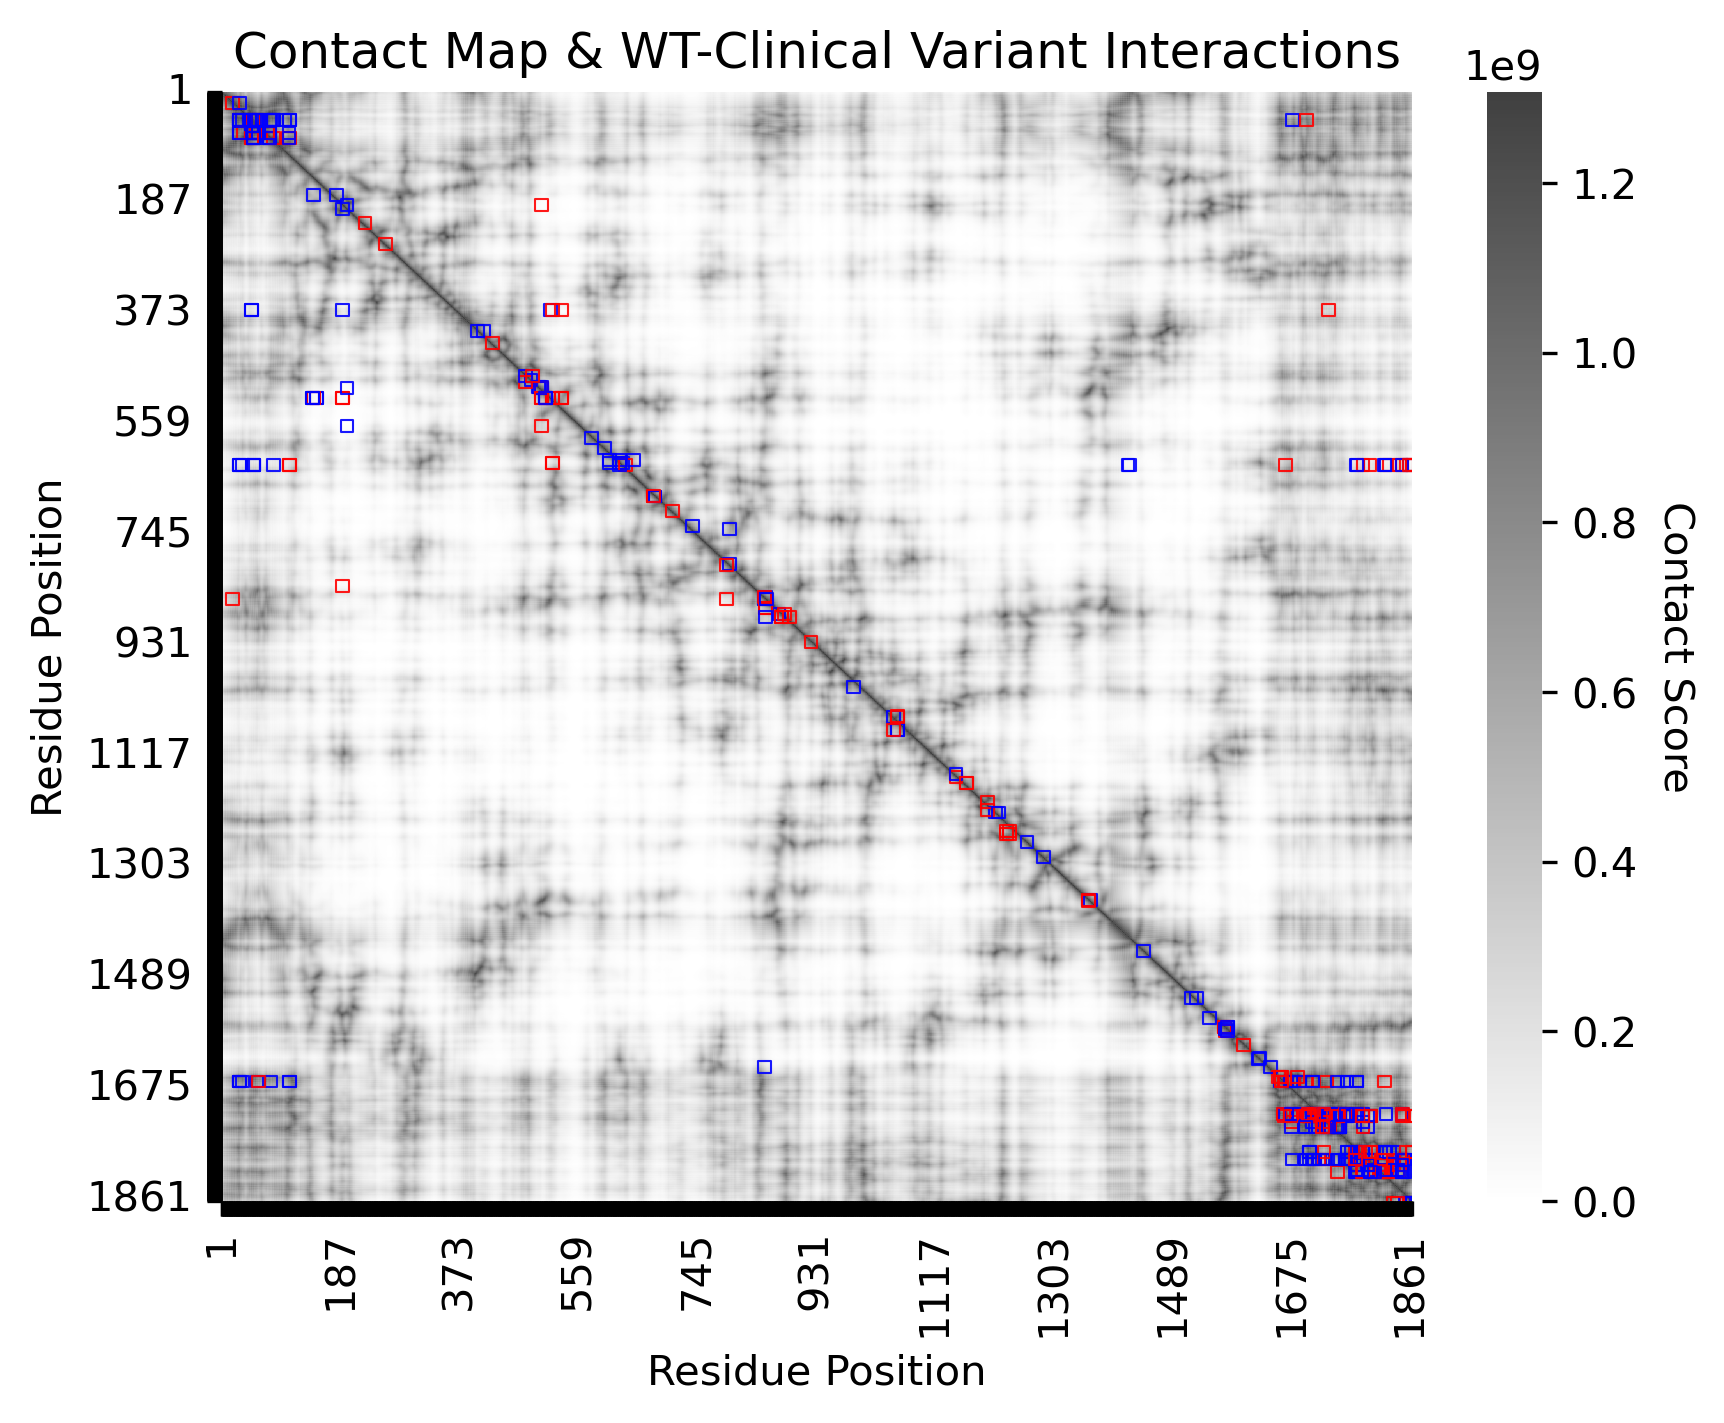

In [210]:
fig2c = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=contact_map_ref_binned,
    outlier_sig=top_interactions, 
    heatmap_alpha=0.75,
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=rf"Contact Map & WT-Clinical Variant Interactions",# +"\n"+rf"(Interaction Strength $\geq$ {interaction_threshold})",
    show_plot=(False, True),
    # figsize=(10, 10)
)
fig2c["fig"]["subplot2"].savefig("manuscript/fig/fig2c.png", **utils.FIG_SAVE_KWARGS)

### Figure 2D

Contact enrichment: outlier detection method

In [211]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

100%|██████████| 50/50 [00:03<00:00, 15.73it/s]


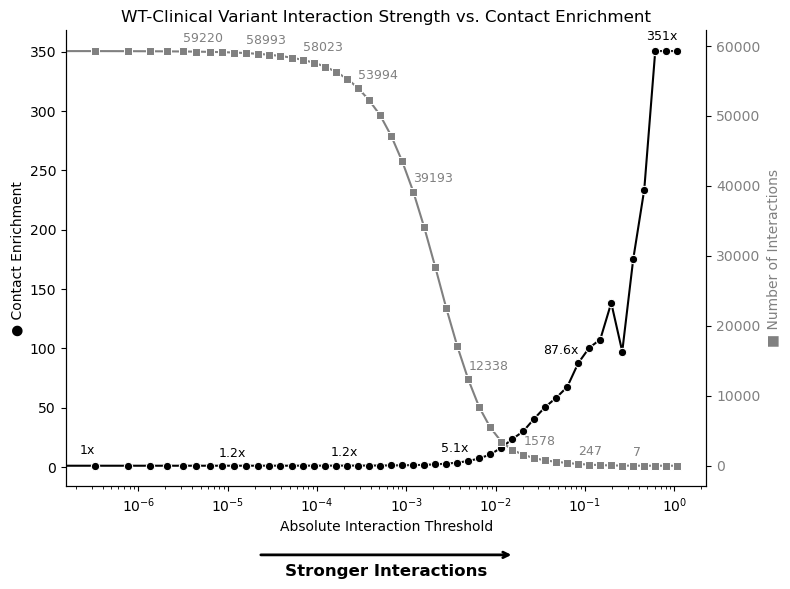

In [46]:
fig2d = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                           figsize=(8, 6),
                                   log_x_axis=True, 
                                   y1_first_label=True,
                                   y1_last_label=True,
                                   y2_first_label=True,
                                   y2_last_label=True, )
fig2d["fig"].savefig("manuscript/fig/fig2d.png", **utils.FIG_SAVE_KWARGS)

### Figure 2E

Mean interaction strength per clinical variant.

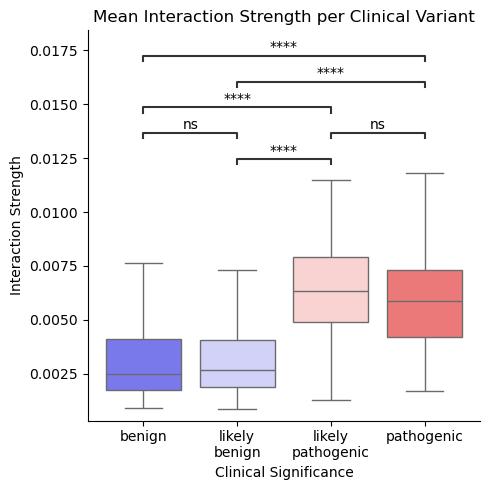

In [36]:
fig2e = ab.plot_clinsig_interaction_strength(
    ridge_df, vep_prot,
    title="Mean Interaction Strength per Clinical Variant",
    xlabel="Clinical Significance",
    ylabel="Interaction Strength", 
    text_format="star",
    figsize=(5, 5),
)
fig2e["fig"].savefig("manuscript/fig/fig2e.png", **utils.FIG_SAVE_KWARGS)

### Figure 2F

Interaction strength vs. Angstroms.

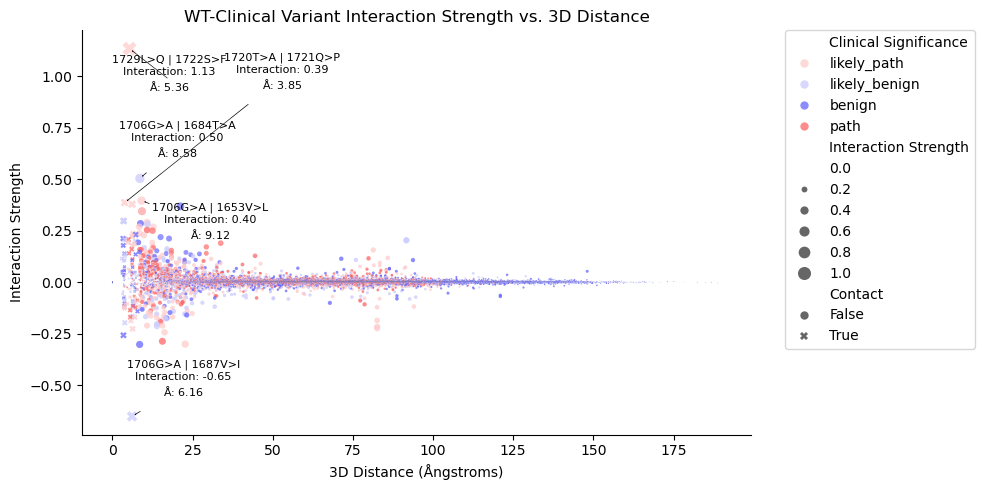

In [ ]:
# Use a lambda to pass contact_map_ref as a closure variable, avoiding the error
ridge_df["position_distance"] = (ridge_df["wt_position"] - ridge_df["clinical_position"]).abs()
ridge_df["Angstroms"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_dist_ref), axis=1)
ridge_df["is_contact"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_binary_ref)==1, axis=1) 
ridge_df["clinical_variant_fmt"] = ridge_df["clinical_variant"].apply(
    lambda x: (
        f"{x[1:-1]}{x[0]}>{x[-1]}"
        if isinstance(x, str) and len(x) >= 3 and x[1:-1].isdigit()
        else x
    )
)
ridge_df['protein'] = ridge_df['site'].str.split(":").str[0]
ridge_df = utils.add_hgvsp_id(ridge_df)

fig2f = ab.plot_wt_clinical_interaction_vs_angstroms(ridge_df, vep_prot, N=5)
fig2f["fig"].savefig("manuscript/fig/fig2f.png", **utils.FIG_SAVE_KWARGS)

Check the baseline enrichment of all interactions with the top WT variant.

In [ ]:
ridge_enrichment_at_threshold_1729LQ = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df.loc[(ridge_df["wt_variant"]=='1729L>Q')],
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[0,],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)
ridge_enrichment_at_threshold_1729LQ

100%|██████████| 1/1 [00:00<00:00, 17.35it/s]


,observed_prob,expected_prob,binom_test,enrichment,interaction_threshold,n_interactions
0,0.008571,0.002852,"BinomTestResult(k=3, n=350, alternative='two-s...",3.004995,0,456


### Figure 2G
Personalized contact maps vs. REF contact map. 

In [34]:
#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1 ) 

contact_maps = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True)  

126 PDB files found


100%|██████████| 126/126 [00:32<00:00,  3.93it/s]


In [35]:
top_wt_variants = ridge_df.groupby("wt_variant")["interaction_strength"].mean().sort_values(ascending=False)
contact_maps_wt = {k:v for k,v in contact_maps.items() if top_wt_variants.index[0].replace(">","_") in k or k==cf.get_ref_key(contact_maps)}
top_wt_variants.head()

wt_variant
1710G>R    0.022135
1706G>A    0.018714
1783M>T    0.017807
616delS    0.016924
1652M>I    0.013827
Name: interaction_strength, dtype: float64

<string>:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


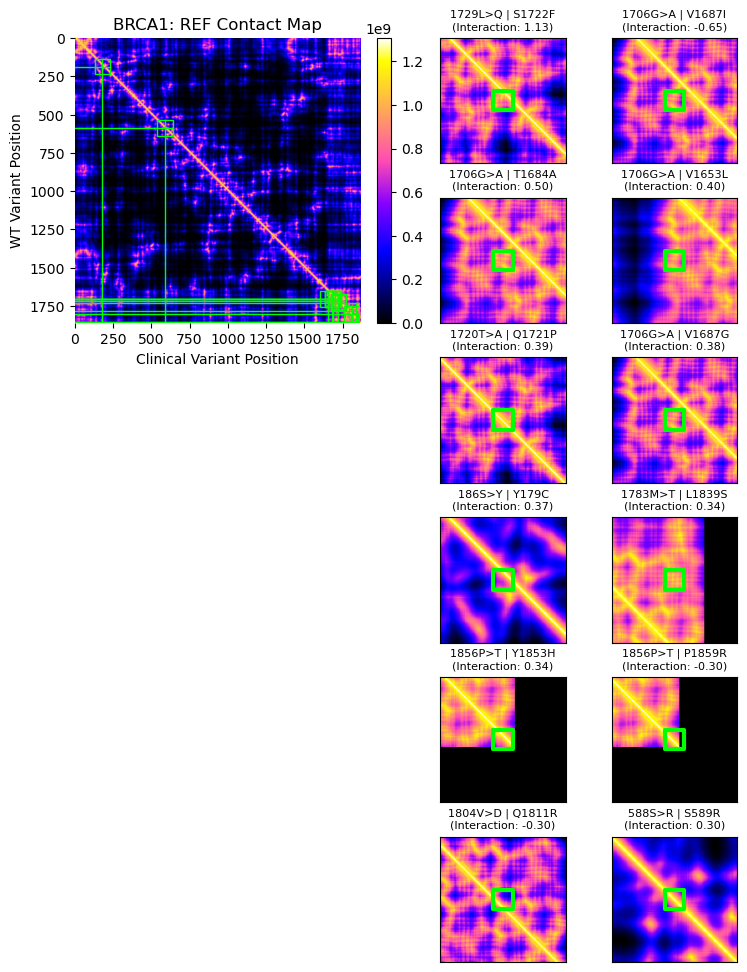

In [39]:
fig2g = cf.plot_contact_map_and_zooms(
    contact_maps_wt,
    ridge_df,
    target_gene, 
    main_plot_above=False,
    max_highlights=12,
    highlight_size=100,
    zoom_nrows = 6,
    zoom_ncols=None,
    zoom_subplot_size = 2,
    main_nrows = 2,
    main_ncols = 2,
    pow=4,
    main_padding=0.25,
    save_path="manuscript/fig/fig2g.png"
)

### Figure 2H

Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

In [40]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

  0%|          | 0/126 [00:00<?, ?it/s]

100%|██████████| 126/126 [00:31<00:00,  3.97it/s]


In [41]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

# Get a merged FASTA file
merged_fasta = hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                        tx_ids=[tx_id],
                        save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                        split_subdir="",
                        # force=True,
                        compress=False) 

# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 


Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


...

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 144 haplotypes across 1 tx_ids.


Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Padding contact maps to MSA: 100%|██████████| 126/126 [00:03<00:00, 38.76it/s]


In [193]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7860, 16)
>> haplotype(s): 144
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    41
EAS    20
SAS    16
AMR    14
EUR    13
MID     8
OCE     4
CSA     2
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 81.94%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000350283:1028R>H,0.000000,0.004902,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,AMR,0.004902,1,AMR,4.0
1,"ENSP00000350283:1038E>G,1183K>R,1613S>G",0.000000,0.000000,0.0,0.0,0.000000,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,0.003289,1,MID,1.0
2,"ENSP00000350283:1038E>G,1613S>G",0.000000,0.000000,0.0,0.0,0.003012,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,MID,0.003289,2,None,NaN
3,ENSP00000350283:1040S>N,0.000791,0.017157,0.0,0.0,0.020331,0.006579,0.0,0.000992,2.0,14.0,0.0,0.0,27.0,2.0,0.0,1.0,EUR,0.020331,5,None,NaN
4,ENSP00000350283:1099P>L,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.002976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,SAS,0.002976,1,SAS,3.0


In [197]:
pop_contact_maps = cf.compute_population_specific_contact_maps(
    contact_maps=contact_maps,
    contact_maps_binary=contact_maps_binary,
    freq_df=freq_df, 
    superpopulation_specific_only=False,
    exclude_ref_from_weights=True,
    weight_binary_maps=True,
)
specific_maps = pop_contact_maps["specific_maps"]
specific_diff_maps = pop_contact_maps["specific_diff_maps"]
specific_binary_diff_maps = pop_contact_maps["specific_binary_diff_maps"]
specific_binary_diff_figs = pop_contact_maps["specific_binary_diff_figs"]

100%|██████████| 8/8 [00:25<00:00,  3.21s/it]


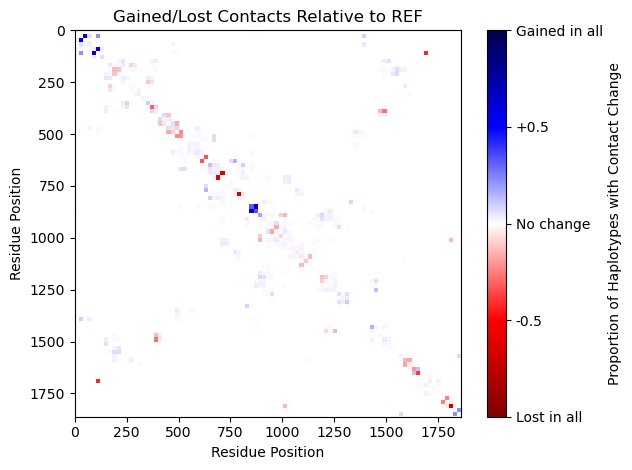

In [ ]:
fig1g = cf.plot_contact_map_diff(contact_maps_binary,  
                                weights=None,
                                show_plot=True,
                                verbose=False)
fig1g["fig"].savefig("manuscript/fig/fig1g.png", **utils.FIG_SAVE_KWARGS)

### Figure 2I

In [199]:
%%capture

fig_superop_diff = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True,
    show_plot=False
)

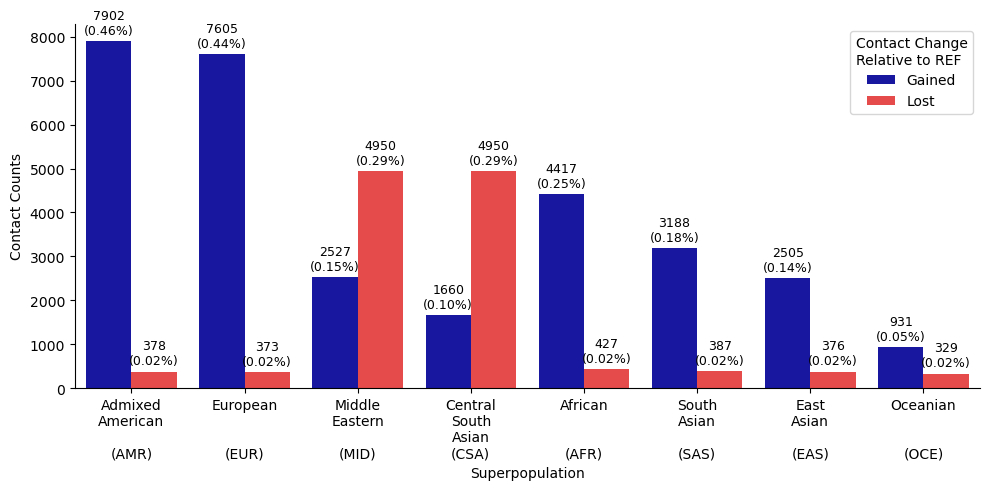

In [ ]:
fig2h = cf.plot_contact_map_diff_barplot_grouped(
    bar_df=fig_superop_diff['data'],
    group_by="superpopulation", 
    )
fig2h['fig'].savefig("manuscript/fig/fig2i.png", **utils.FIG_SAVE_KWARGS)


## Figure 3

In [ ]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)

# Standardise clinical significance labels
spliceai_df["clinsig"] = spliceai_df["CLNSIG_simplified"].astype(str)
likely_mask = spliceai_df["CLNSIG"].str.lower().str.contains("likely").fillna(False)
spliceai_df.loc[likely_mask, "clinsig"] = "likely_"+spliceai_df.loc[likely_mask, "clinsig"]
spliceai_df.replace({"clinsig": {"vus": "VUS"}}, inplace=True)
spliceai_df = spliceai_df[~spliceai_df["clinsig"].isin([np.str_('nan'), 'nan'])]
spliceai_df["clinsig_simple"] = spliceai_df["clinsig"].str.replace("likely_", "")

### Figure 3A

SpliceAI VEP distributions stratified by clinical significance categories.

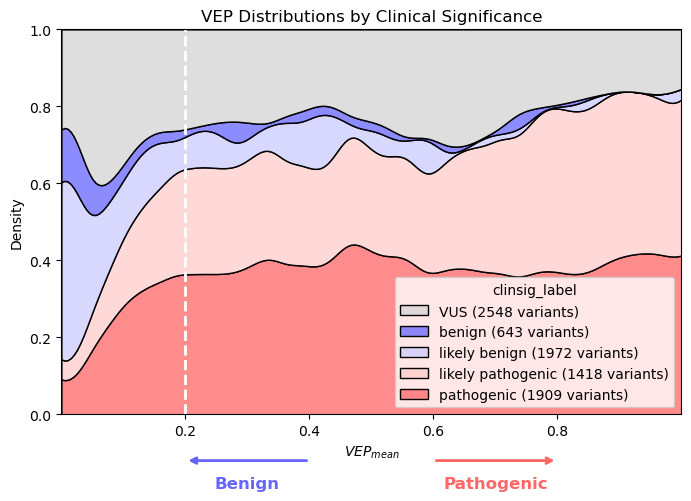

In [ ]:
fig3a = db.plot_vep_kde_with_arrows(vep_df=spliceai_df, 
                                    save_path="manuscript/fig/fig3a.png")

### Figure 3B

Dataset summary statistics.

- WT variants per person (can get from VCFs)
- WT variants per haplotype in the SpliceAI/Flashzoi regions used (can get from GVL datasets with `.n_variants`)
- Number of clinical variants per gene
- Proportion of SpliceAI VEPs that were of each score type (stratified by pathogenicity/splicegenicity)
- Proportion of Flashzoi VEPs that were of each 5' or 3' UTR

/tmp/ipykernel_1568063/2679667578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spliceai_df["clinsig_simple"] = spliceai_df["clinsig"].str.replace("likely_", "")


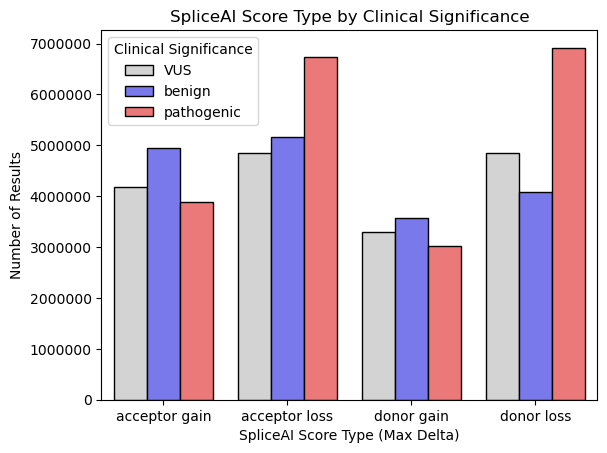

In [ ]:
source_type_counts = spliceai_df.groupby(["clinsig_simple","max_delta_score_type"], observed=True).size().reset_index(name="count")
source_type_counts["max_delta_score_type"] = source_type_counts["max_delta_score_type"].str.replace("_"," ")
source_type_counts, palette_labeled = db.fix_clinsig_labels(source_type_counts, clinsig_col="clinsig_simple", mutant_col="site")

ax = sns.barplot(
    data=source_type_counts,
    x="max_delta_score_type",
    y="count",
    hue="clinsig_simple_label",
    palette=palette_labeled,
    edgecolor="black",  # Add black lines around bars
    linewidth=1         # Set line width for the bar edges
)
plt.legend(title="Clinical Significance")
plt.xlabel("SpliceAI Score Type (Max Delta)")
plt.ylabel("Number of Results")
plt.title("SpliceAI Score Type by Clinical Significance")
ax.ticklabel_format(style='plain', axis='y')  # Disable scientific notation for y-axis
plt.savefig("manuscript/fig/fig3b.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1568063/68355966.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entropy_df = spliceai_df.groupby(["clinsig_simple","site"], observed=True).apply(lambda x: entropy(x["max_delta_score_type"].value_counts(normalize=True), base=2)).reset_index(name="entropy")


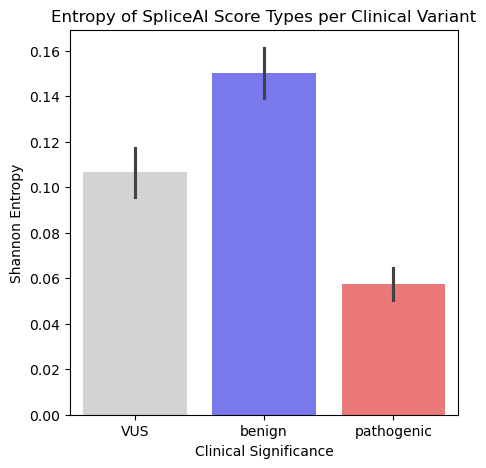

In [ ]:
from scipy.stats import entropy

entropy_df = spliceai_df.groupby(["clinsig_simple","site"], observed=True).apply(lambda x: entropy(x["max_delta_score_type"].value_counts(normalize=True), base=2)).reset_index(name="entropy")

plt.figure(figsize=(5, 5))

sns.barplot(data=entropy_df, 
               x="clinsig_simple", 
               y="entropy", 
               hue="clinsig_simple", 
               legend=False,
               palette=utils.get_clinsig_palette(), )
plt.xlabel("Clinical Significance")
plt.ylabel("Shannon Entropy")
plt.title("Entropy of SpliceAI Score Types per Clinical Variant")
plt.savefig("manuscript/fig/fig3c.png", **utils.FIG_SAVE_KWARGS)

---

---

## Figure S1

Plot VEP distributions for each combination of model and scoring strategy.

#### Protein sequence models

In [ ]:
force = False
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy'] 
vep_agg =[]
vep_counts = []
for model_location in va.list_all_models():

    print(f"Processing {model_location}")
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)
    vep_counts.append(vep_tmp.shape[0])
    vep_agg.append(vep_tmp.groupby(groupby_cols, observed=True)["VEP"].mean().reset_index())
     

vep_agg = pd.concat(vep_agg)
print("Total VEP results:",sum(vep_counts))
vep_agg.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Processing esm2_t12_35M_UR50D
Loading results/data/vep_df_esm2_t12_35M_UR50D.parquet
Processing esm1b_t33_650M_UR50S
Loading results/data/vep_df_esm1b_t33_650M_UR50S.parquet
Processing esm2_t33_650M_UR50D
No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 202449 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 1
scoring_strategy: 3
variant_set: 1
haplotype: 111378
protein: 2250
No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 111378 masked-marginals parquet files


Reading files:   0%|          | 0/111378 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


...

Reading files:   0%|          | 0/111457 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 5.25GB/s]


VEP dataframe shape: (3829179, 73)
Saving results/data/vep_df_esmc_600m.parquet


,model_location,protein,clinsig,mutant,scoring_strategy,VEP
0,esm2_t12_35M_UR50D,NP_000007.1,benign,C159W,masked-marginals,-4.259397
1,esm2_t12_35M_UR50D,NP_000007.1,likely_benign,M87I,masked-marginals,-0.187846
2,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A113T,masked-marginals,-4.230541
3,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A165T,masked-marginals,-2.380263
4,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A81T,masked-marginals,-2.507311


In [6]:
vep_agg.groupby('model_location').size().sort_values(ascending=False)

model_location
esm1_t34_670M_UR50D       56379
esmc_600m                 56379
esm2_t33_650M_UR50D       56364
esm3_sm_open_v1           56364
esm2_t12_35M_UR50D        53402
esm1v_t33_650M_UR90S_1    35659
esm1b_t33_650M_UR50S      34964
esm2_t48_15B_UR50D         8319
esm1_t6_43M_UR50S          1757
dtype: int64

Filtered 0.2% of rows with NAs in col 'VEP'


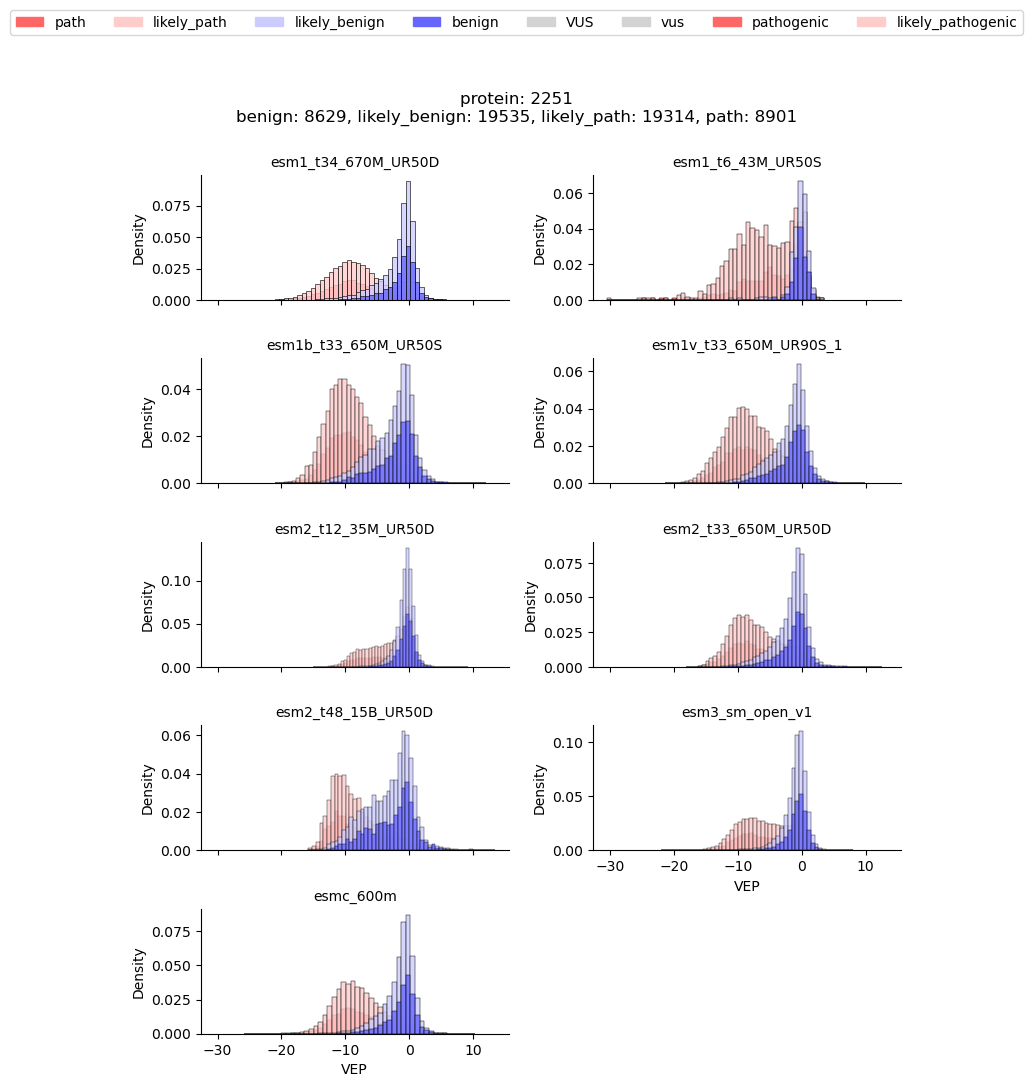

In [47]:
figS1 = va.plot_vep_density(vep_agg.sort_values(by='model_location'), 
                     multiple=['layer','stack','fill'][0],
                     row=None,
                     col='model_location',    
                     plot_func=sns.histplot,
                     stat='density',
                     bins=50,
                     facetgrid_kwargs={'col_wrap': 2}, 
                     height=2,
                     aspect=2,
                     save_path="results/plots/vep_density.png"
                     )
figS1['fig'].savefig("manuscript/fig/figS1.png", **utils.FIG_SAVE_KWARGS)

In [54]:
vep_diff_df, vep_diff_summary = db.test_vep_clinsig_separation(vep_agg)
vep_diff_summary

,pvalue,statistic
model_location,,
esmc_600m,1.939497e-08,1.507877e+08
esm2_t33_650M_UR50D,2.205292e-04,1.464150e+08
esm1_t34_670M_UR50D,9.101600e-07,1.448694e+08
esm3_sm_open_v1,3.546757e-05,1.418671e+08
esm2_t12_35M_UR50D,2.079269e-03,1.145610e+08
esm1b_t33_650M_UR50S,1.259272e-01,5.662216e+07
esm1v_t33_650M_UR90S_1,4.195902e-02,5.624953e+07
esm2_t48_15B_UR50D,5.156835e-02,3.089960e+06
esm1_t6_43M_UR50S,1.649432e-01,1.093967e+05


### DNA sequence models

Import Flashzoi VEP results.

In [ ]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
) 
pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")

flashzoi_df = pd.read_parquet(pq_file)
if "VEP" not in flashzoi_df.columns:
    flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"] 
if "site" not in flashzoi_df.columns:
    flashzoi_df.rename(columns={"site_x": "site"}, inplace=True)
flashzoi_df["protein"] = flashzoi_df["GENE"] 

,index,site_x,sample,ploid,slot,evo2_40b_base,evo2_40b,evo2_7b_base,spliceai,evo2_7b,dnabert2,spliceai_mm,flashzoi,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,site_y,MONDO,MONDO_n,OMIM,OMIM_n,Orphanet,Orphanet_n,MedGen,MedGen_n,MeSH,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE,flashzoi_norm,VEP
0,0,chr20:23047426-23047427_T_C,REF,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.730848,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.174794,-0.174794
1,14,chr20:23047426-23047427_T_C,REF,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.592481,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.472828,-0.472828
2,28,chr20:23047426-23047427_T_C,HG00096,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.695581,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.250758,-0.250758
3,42,chr20:23047426-23047427_T_C,HG00096,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.638817,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.373023,-0.373023
4,56,chr20:23047426-23047427_T_C,HG00097,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.546913,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.570978,-0.570978


Import SpliceAI VEP results.

In [ ]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)
spliceai_df["protein"] = spliceai_df["gene"]

In [87]:
clnsig_map = {"likely_pathogenic": "likely_path",
                    "pathogenic": "path", 
                    "benign": "benign",
                    "vus": "VUS",
                    "likely_benign": "likely_benign"}

vep_dna_agg = [] 
flashzoi_df.rename(columns={"site_x":"site"}, inplace=True)
flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"]
flashzoi_df["clinsig"] = flashzoi_df["CLNSIG_simple"]#.map(clnsig_map)
agg = flashzoi_df.groupby(['site','clinsig'], observed=True)["VEP"].mean().reset_index()
agg["model_location"] = "Flashzoi"
vep_dna_agg.append(agg)

spliceai_df["clinsig"] = spliceai_df["CLNSIG_simplified"].map(clnsig_map)
agg = spliceai_df.groupby(['site','clinsig'], observed=True)["VEP"].mean().reset_index()
agg["model_location"] = "SpliceAI"
vep_dna_agg.append(agg)

vep_dna_agg = pd.concat(vep_dna_agg, ignore_index=True)
vep_dna_agg.head()

,site,clinsig,VEP,model_location
0,chr11:10294187-10294188_C_A,likely_benign,0.981774,Flashzoi
1,chr11:10506578-10506579_A_G,benign,0.030980,Flashzoi
2,chr11:10506936-10506937_A_G,benign,0.057640,Flashzoi
3,chr11:10506954-10506955_A_G,benign,0.459897,Flashzoi
4,chr11:10506974-10506975_A_G,benign,0.005592,Flashzoi


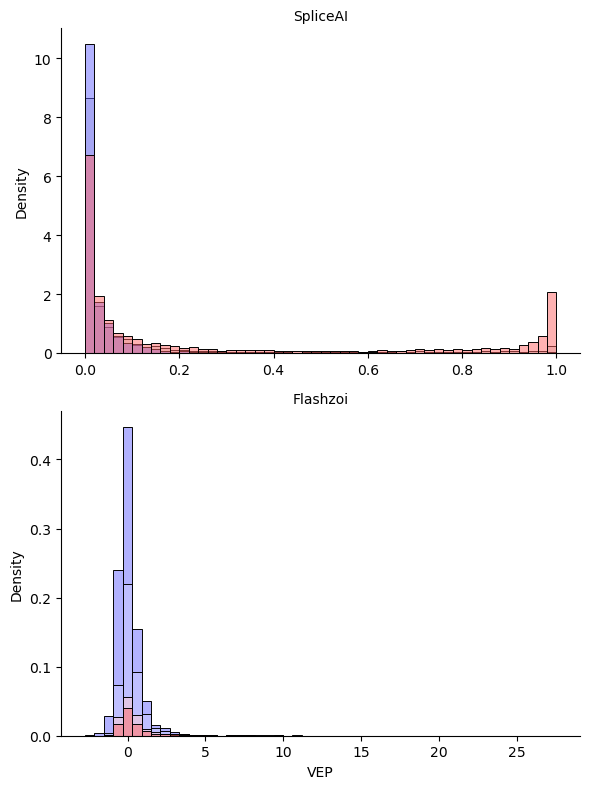

In [109]:
palette = utils.get_clinsig_palette() 
vep_dna_agg = utils.sort_by_clinsig(vep_dna_agg)

g1= sns.FacetGrid(
    vep_dna_agg,
    col="model_location",
    col_wrap=1,
    height=4,
    aspect=1.5,
    sharex=False,
    sharey=False,
    legend_out=False  # Set to False so legend is drawn on the facet
)
g1.map_dataframe(
    sns.histplot,
    x="VEP",
    hue="clinsig",
    palette=palette,
    multiple="layer",
    stat="density",
    bins=50,
    legend=True
)
va.rm_subplot_prefixes(g1)
# Show legend for each facet
for ax in g1.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, title="clinsig")
g1.figure.tight_layout()

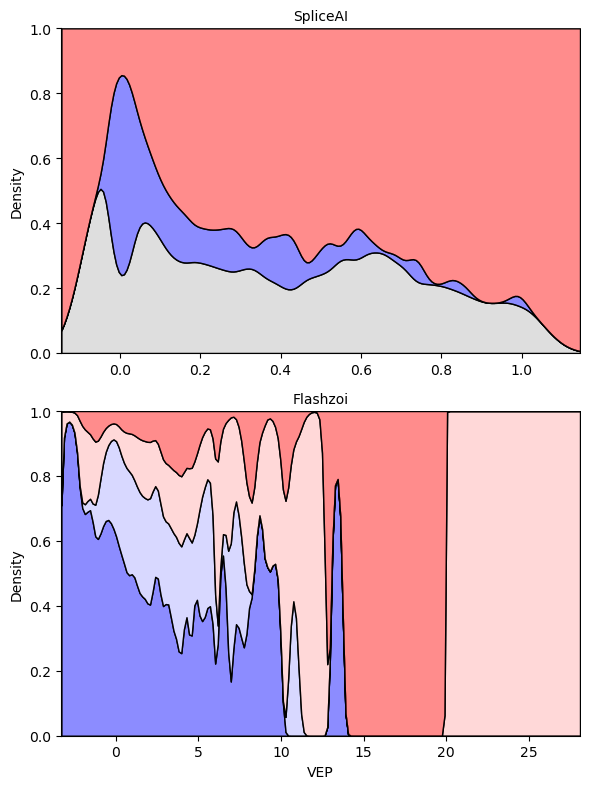

In [106]:
palette = utils.get_clinsig_palette() 
vep_dna_agg = utils.sort_by_clinsig(vep_dna_agg)

g2 = sns.FacetGrid(
    vep_dna_agg,
    col="model_location",
    col_wrap=1,
    height=4,
    aspect=1.5,
    sharex=False,
    sharey=False,
    legend_out=False  # Set to False so legend is drawn on the facet
)
g2.map_dataframe(
    sns.kdeplot,
    x="VEP",
    hue="clinsig",
    multiple="fill",
    fill=True,
    palette=palette, 
    legend=True
)
va.rm_subplot_prefixes(g2)
# Show legend for each facet
for ax in g2.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, title="clinsig")
g2.figure.tight_layout()

## Figure S2

In [55]:
vep_df = va.compute_representativeness_stats(vep_df, is_ref=False)

In [56]:
vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy", "mutant"])["haplotype"].transform("nunique")

In [57]:
#### Violin plot version ####
# fig1f_vio = db.plot_vep_percentiles(vep_df, row=None, col=None, height=5, aspect=1.5, x_rotation=0, x_ha='center')

In [76]:
groupby_cols = ['model_location','protein','clinsig','mutant','site','scoring_strategy']
normality_results = db.test_normality(vep_df,
                                      min_n=20,
                                      groupby_cols=groupby_cols,
                                      save_path='results/normality_results.parquet')
normality_results.head()

  0%|          | 0/56364 [00:00<?, ?it/s]

Saving normality results


metric,model_location,protein,clinsig,mutant,site,scoring_strategy,n_samples,pvalue,statistic
0,esm2_t33_650M_UR50D,NP_000007.1,benign,C159W,NP_000007.1:C159W,masked-marginals,26.0,0.288377,2.486977
1,esm2_t33_650M_UR50D,NP_000007.1,likely_benign,M87I,NP_000007.1:M87I,masked-marginals,26.0,0.000002,25.841743
2,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A113T,NP_000007.1:A113T,masked-marginals,26.0,0.008392,9.560975
3,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A165T,NP_000007.1:A165T,masked-marginals,26.0,0.000017,21.954090
4,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A81T,NP_000007.1:A81T,masked-marginals,26.0,0.001276,13.327450


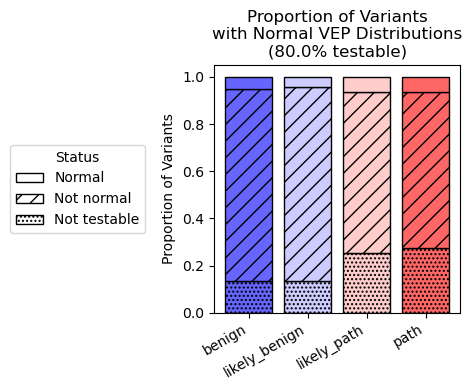

Total proteins: 2250
Total sites: 56364
Sites with normal distribution (Testable): 45089.03316213845 (80.00%)
Sites with normal distribution (True): 3178.2121221624743 (5.64%)
Sites with non-normal distribution: 41910.82103997596 (74.36%)


In [77]:
figS2a = db.plot_test_normality(normality_results, 
                                figsize=(5, 4), 
                                legend_left=True, 
                                )
figS2a['fig'].savefig("manuscript/fig/figS2a.png", **utils.FIG_SAVE_KWARGS)

### Figure S2c

Estimate the modallity for each VEP distribution.

In [45]:
vep_ecdf = db.estimate_modality(
    vep_df=vep_df,  
    save_path='results/vep_ecdf.parquet',
    min_haplotypes=20,
    max_components=50,
    force=False
    )  
vep_ecdf["n_peaks"].min(),  vep_ecdf["n_peaks"].max(), vep_ecdf["n_peaks"].median()

Loading cached ECDF data
(4578200, 21)


(np.int64(1), np.int64(6), np.float64(2.0))

Remaining sites @ n_haplotypes >= 20: 43643 / 45782 = 95.3278581102%


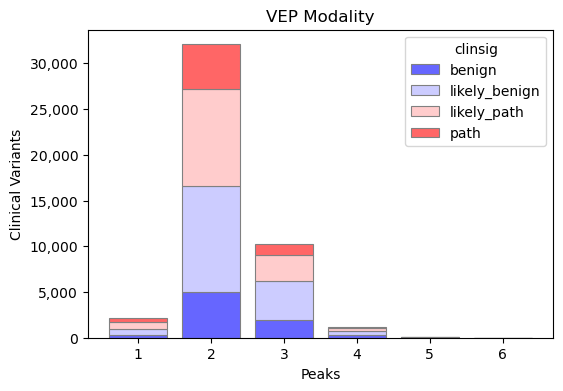

clinsig,n_peaks,benign,likely_benign,likely_path,path,total
0,1,293,611,854,381,2139
1,2,5011,11550,10685,4830,32076
2,3,1925,4272,2805,1270,10272
3,4,254,533,275,121,1183
4,5,24,54,21,8,107
5,6,1,3,1,0,5


In [62]:
figS2b = db.plot_estimate_modality(vep_ecdf,
                                    min_haplotypes=20, 
                                    figsize=(6, 4))
figS2b['fig'].savefig("manuscript/fig/figS2b.png", **utils.FIG_SAVE_KWARGS)
peak_counts =figS2b['data'].reset_index()
peak_counts

In [70]:
peak_counts.loc[peak_counts['n_peaks']>1]['total'].sum()

np.int64(43643)

In [ ]:
# Proportion of variants with >1 peak
100-peak_counts.loc[peak_counts['n_peaks']==1]['total'].sum() / peak_counts['total'].sum()*100

np.float64(95.3278581101743)

In [ ]:
# Proportion of all variants tested for modality
figS2b['data']['total'].sum()/vep_df['site'].nunique()*100

np.float64(81.2256049960968)

### Figure S2c

Reference representativeness: VEP standard deviation.

/home/schilder/projects/VEP_protein/src/analysis/distributions.py:1744: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Plot a stacked bar plot of VEP percentiles, binned by quantiles and standard deviation categories.


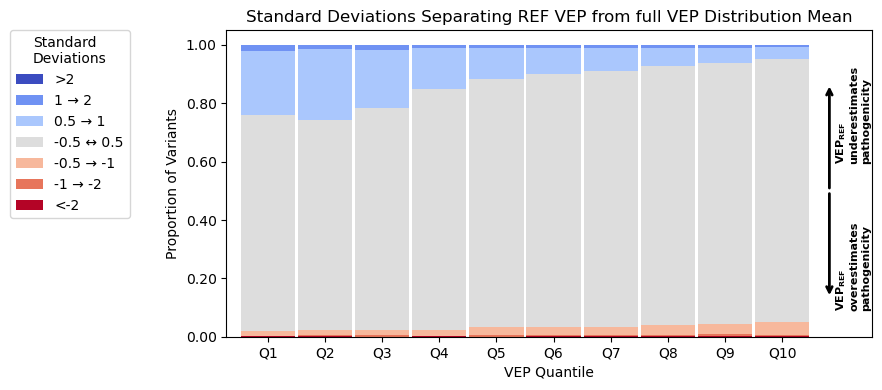

In [78]:
#### Standard Deviation version ####

# Limit to variants with normal VEP distributions
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
vep_sub = vep_df.merge(
    normality_results.loc[normality_results["pvalue"] >= 0.05],
    on=groupby_cols,
    how="left"
) 
figS2c_std = db.plot_ref_vep_std_stacked_bar(vep_sub)
figS2c_std['fig'].savefig("manuscript/fig/figS2c.png", **utils.FIG_SAVE_KWARGS)

In [79]:
figS2c_std['data'].groupby('VEP_pct_group_cat').size() / figS2c_std['data'].groupby('VEP_pct_group_cat').size().sum()*100

/tmp/ipykernel_2798356/1111334276.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  figS2c_std['data'].groupby('VEP_pct_group_cat').size() / figS2c_std['data'].groupby('VEP_pct_group_cat').size().sum()*100
/tmp/ipykernel_2798356/1111334276.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  figS2c_std['data'].groupby('VEP_pct_group_cat').size() / figS2c_std['data'].groupby('VEP_pct_group_cat').size().sum()*100


VEP_pct_group_cat
<-2            0.072744
-1 → -2        1.169227
-0.5 → -1     12.228097
-0.5 ↔ 0.5    83.291934
0.5 → 1        2.677336
1 → 2          0.455981
>2             0.104680
dtype: float64

### Figure S2d

VEP distribution UMAP.

In [175]:
ecdf_umap_df, vep_ecdf_pivot = db.ecdf_to_umap(vep_ecdf)

Running UMAP
UMAP(n_jobs=1, random_state=42, verbose=True)
Thu Sep  4 17:21:56 2025 Construct fuzzy simplicial set
Thu Sep  4 17:21:56 2025 Finding Nearest Neighbors
Thu Sep  4 17:21:56 2025 Building RP forest with 16 trees


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Thu Sep  4 17:21:57 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Thu Sep  4 17:21:58 2025 Finished Nearest Neighbor Search
Thu Sep  4 17:21:58 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu Sep  4 17:23:21 2025 Finished embedding


In [176]:
ecdf_umap_df, vep_ecdf_pivot =  db.cluster_and_annotate_umap(ecdf_umap_df, 
                                                             vep_ecdf_pivot,  
                                                             n_samples=None, 
                                                             method='kmeans',
                                                             n_clusters=20,
                                                            #  cluster_on_umap=True,
                                                            #  cluster_kwargs={'eps':.01, 'min_samples':100},
                                                             show_dendrogram=False)

Number of clusters (kmeans): 20
Cluster distribution:
cluster
1     3050
2     2437
3     1138
4     2293
5     1750
6     1977
7     2470
8     2052
9     1868
10    1694
11    2267
12    2417
13    2386
14    2106
15    2709
16    2756
17    2284
18    2715
19    2833
20    2580
Name: count, dtype: int64


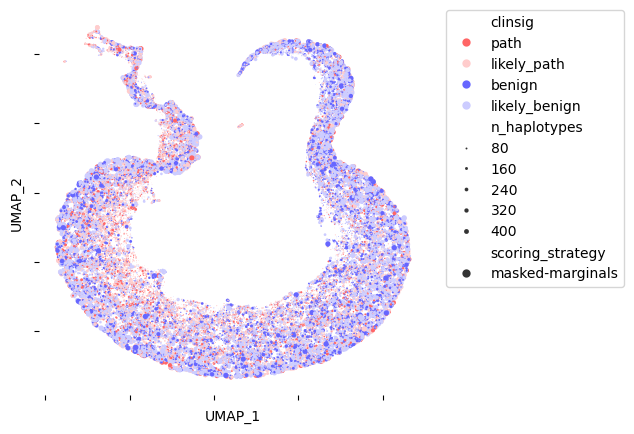

In [186]:
figS2d = db.plot_cluster_umap(ecdf_umap_df,  
                     hue_var="clinsig",
                     palette=utils.get_clinsig_palette(),
                     figsize=(5, 5))
figS2d['fig'].savefig("manuscript/fig/figS2d.png", **utils.FIG_SAVE_KWARGS)                    

<string>:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


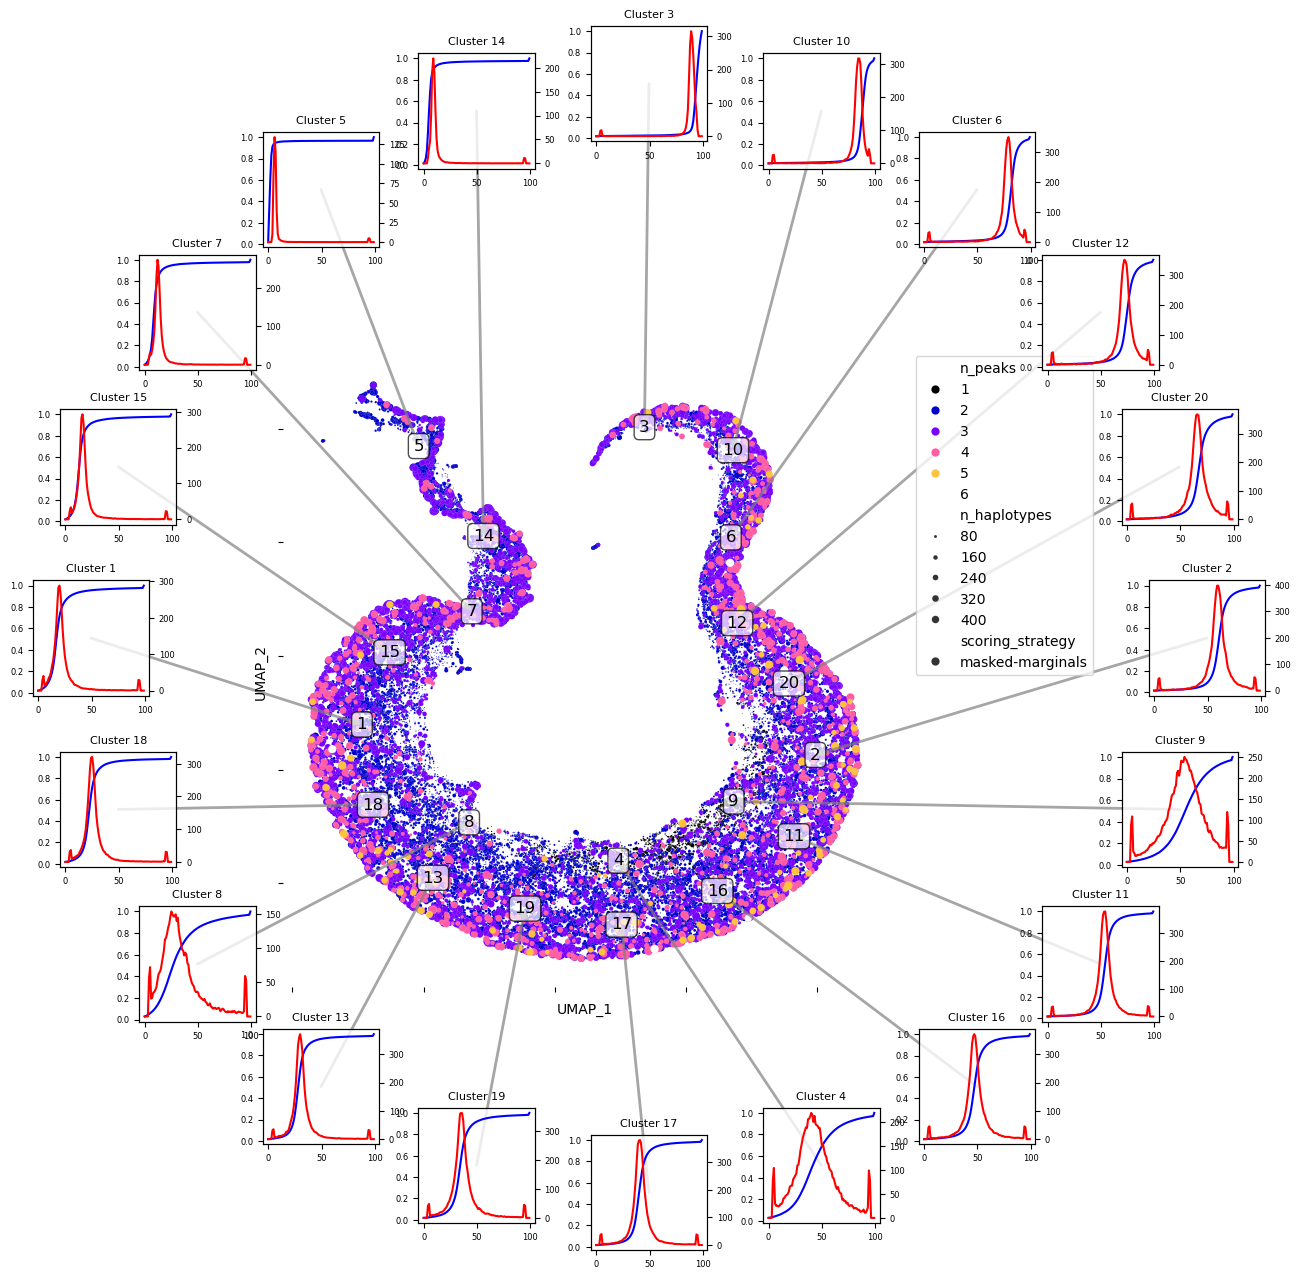

In [188]:
figS2e = db.plot_cluster_umap_with_distribution_plots(ecdf_umap_df.sort_values(by='n_peaks', ascending=True),
                                                       vep_ecdf, 
                                                       vep_ecdf_pivot, 
                                                      hue='n_peaks',
                                                      palette="gnuplot2",  
                                                      line_color="grey", 
                                                      figsize=(10, 10),
                                                       sizes=(.0001, 35), 
                                                        min_distance=0.8, 
                                                        connector_alpha=0.7)
figS2e['fig'].savefig("manuscript/fig/figS2e.png", **utils.FIG_SAVE_KWARGS)

## Figure S3

Sampling 6 rows from 5
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       5        4


<string>:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


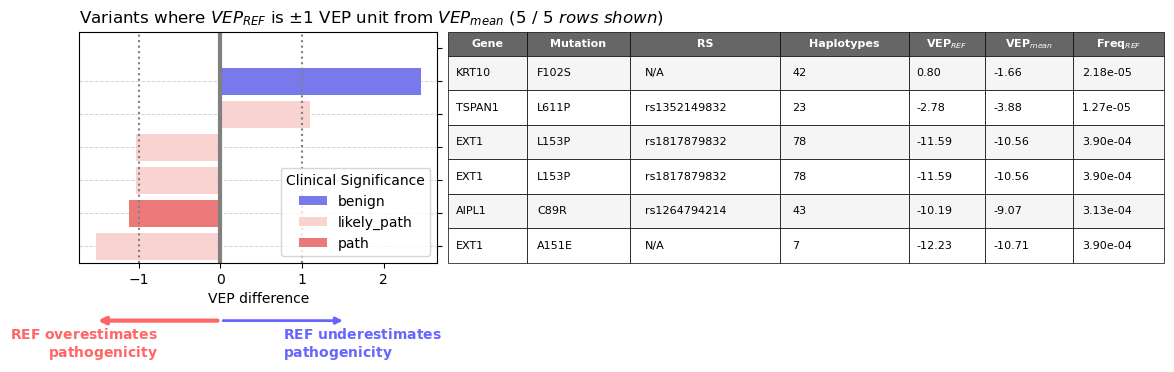

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{mean}}$$\\it{\\ (5\\ /\\ 5\\ rows\\ shown)}$'}, xlabel='VEP difference'>,
 <Axes: >)

In [458]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_mean_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{mean}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=True)

Sampling 6 rows from 695
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       6        5


<string>:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


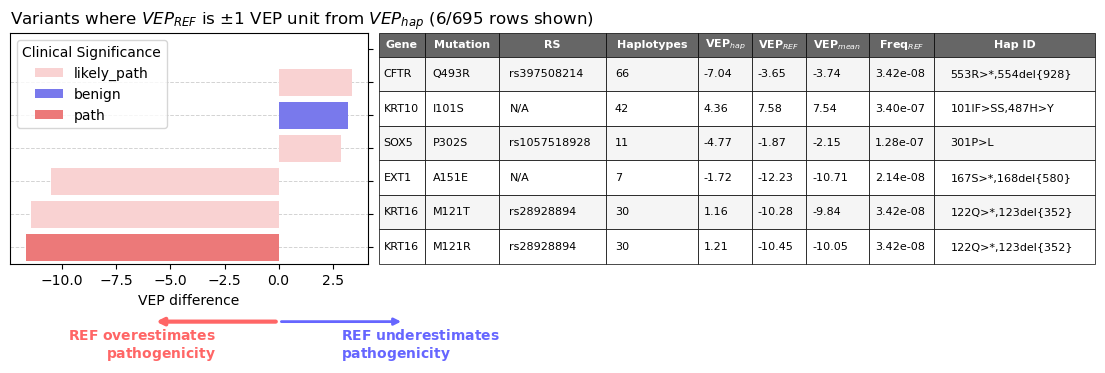

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{hap}}$ (6/695 rows shown)'}, xlabel='VEP difference'>,
 <Axes: >)

In [452]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_ref_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{hap}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=None)

In [460]:
import matplotlib.pyplot as plt

# Create bins: '<-1', '-1 to 1', '>1'
bins = pd.cut(
    vep_df.loc[~vep_df["is_ref"], "VEP_ref_diff"],
    bins=[-float('inf'), -1, 1, float('inf')],
    labels=['<-1', '-1 to 1', '>1']
)
bin_counts = bins.value_counts().sort_index()
bin_counts
 

VEP_ref_diff
<-1           520
-1 to 1    521287
>1            180
Name: count, dtype: int64

## Figure S4

Proportion of gained/lost contacts per superpopulation: weighted proportional to haplotype frequency within each superpopulation.

## Figure S5

Binary pathogenic/benign classifier results.

In [ ]:
lr_dict = {} 
lr_gene_dict = {}
min_values_per_label= 10

### Figure 3A

ESM

In [ ]:
# Gather data from each model and compute logreg results

#### Run for all models ####
from IPython.display import clear_output
force = False

for model_location in va.list_all_models():
    print(f"Processing {model_location}") 
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)

    # Run logreg analysis
    lr_dict[model_location] = bcv.run_clinvar_logreg_analysis(vep_tmp, 
                                                                clinsig_col="clinsig",
                                                                site_col="site") 

    lr_gene_dict[model_location] = bcv.run_clinvar_logreg_analysis_by_group(vep_tmp, 
                                                group_by="protein",
                                                vep_col="VEP",
                                                clinsig_col="clinsig",
                                                min_values_per_label=min_values_per_label,
                                                site_col="site" ) 
    clear_output()
del vep_tmp

#### Run for just the main ESM model ####
# lr_dict[model_name] = bcv.run_clinvar_logreg_analysis(vep_df, 
#                                             clinsig_col="clinsig",
#                                             site_col="site") 
# lr_gene_dict[model_name] = bcv.run_clinvar_logreg_analysis_by_group(vep_df, 
#                                                 group_by="protein",
#                                                 vep_col="VEP",
#                                                 clinsig_col="clinsig",
#                                                 min_values_per_label=min_values_per_label,
#                                                 site_col="site" )
    

### Figure 3B

SpliceAI

In [ ]:
lr_dict['SpliceAI'] = bcv.run_clinvar_logreg_analysis(spliceai_df, 
                                                        clinsig_col="CLNSIG_simplified",
                                                        site_col="site")  

Running logistic regression for REF
Running logistic regression for non-REF


In [ ]:
lr_gene_dict['SpliceAI']= bcv.run_clinvar_logreg_analysis_by_group(spliceai_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simplified",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1836 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

### Figure 3C

Flashzoi

In [ ]:
lr_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis(flashzoi_df, 
                                                        clinsig_col="CLNSIG_simple",
                                                        site_col="site") 

Running logistic regression for REF
Running logistic regression for non-REF


In [ ]:
lr_gene_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis_by_group(flashzoi_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simple",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1464 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Uncorrected for gene bias.

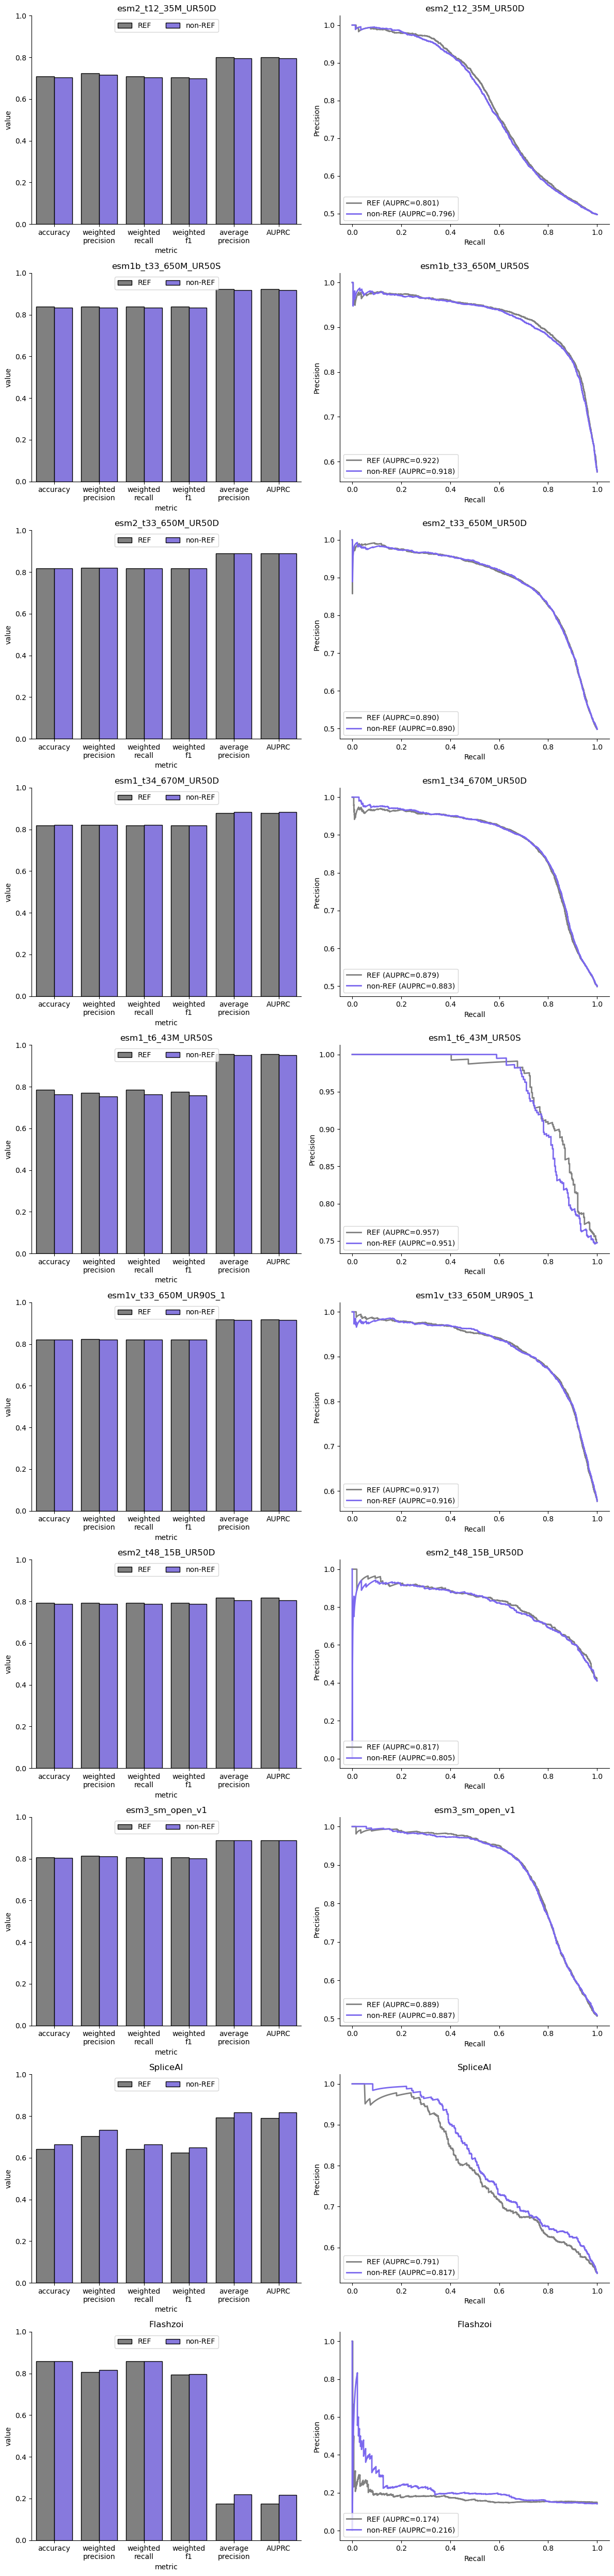

{'fig': <Figure size 1200x5000 with 20 Axes>,
 'axes': array([[<Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes:

In [ ]:
plot_logreg_results_subplots_out = bcv.plot_logreg_results_subplots(
    data_dict = lr_dict,
    figsize = (12, 5),   
)

Corrected for gene bias.

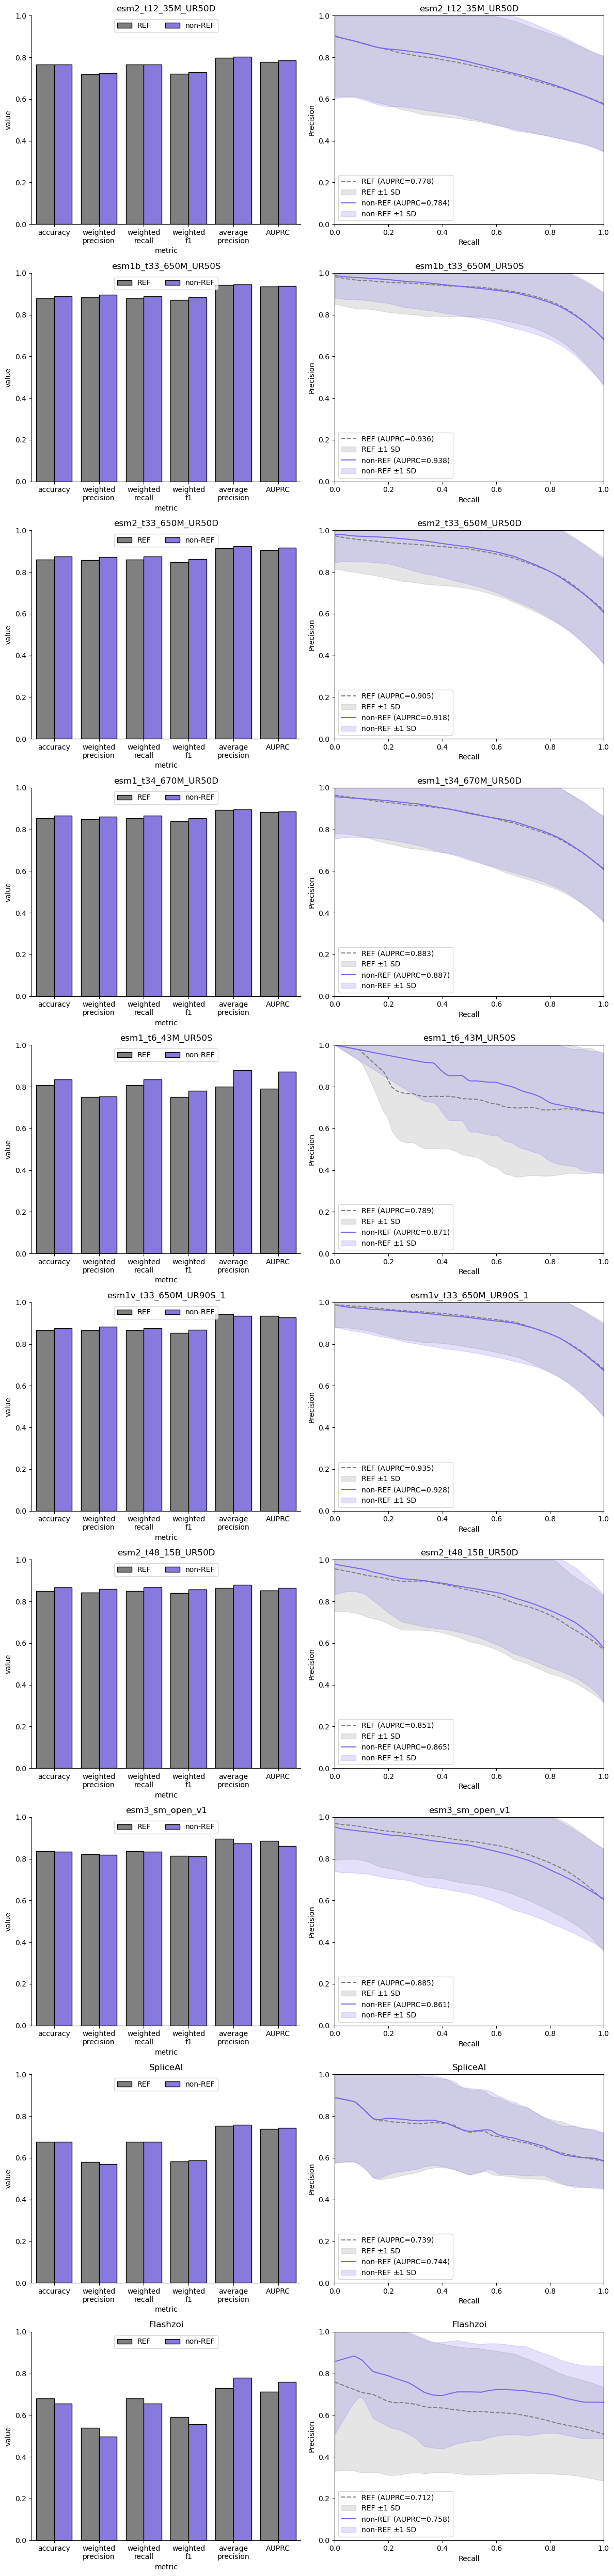

{'fig': <Figure size 1200x5000 with 20 Axes>,
 'axes': array([[<Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes:

In [ ]:
plot_logreg_gene_subplots_out = bcv.plot_logreg_gene_subplots(
    data_dict = lr_gene_dict,
    figsize = (12, 5) 
)

## Figure S6

In [75]:
pg_df = pg.merge_resources()
pg_df.loc[pg_df["genename"]=="TP53"]

ProteinGym: Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
2062,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000269305,ENSP00000269305
2063,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000359597,ENSP00000352610
2064,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000413465,ENSP00000410739
3152,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000269305,ENSP00000269305
3153,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000359597,ENSP00000352610
3154,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000413465,ENSP00000410739


In [123]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882",
               "TP53":"P04637"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":"ENST00000370192",
          "TP53":"ENST00000269305"}  # ENST00000269305, ENST00000359597, ENST00000413465
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2',
              "TP53": 'NP_000537.3'}

# Get specific instance of the protein
target_gene = "TP53"
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

In [124]:

#### Import directly from AlphaFoldDB ####
# structure = cf.import_mmcif(protein_id = uniprot_id)[0]
# contact_map_ref = cf.get_contact_map(structure,  
#                                  return_distance_map=True,
#                                  continuous=True )
# contact_map_dist_ref = cf.get_contact_map(structure,  
#                                return_raw_distance_map=True )

# contact_map_binary_ref = cf.get_contact_map(structure,
#                                                 max_distance=8.0, 
#                                                 continuous=False, 
#                                                 return_distance_map=False) 

# #### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1,
                            ref_only = True) 

contact_map_ref = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True,
                                        as_dict=False)  


contact_map_dist_ref = cf.import_contact_maps(pdb_files,
                                            return_raw_distance_map=True,
                                            as_dict=False)  
contact_map_binary_ref = cf.import_contact_maps(pdb_files,
                                                max_distance=8.0, 
                                                continuous=False, 
                                                return_distance_map=False,
                                                as_dict=False ) 


1 PDB files found


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 42.95it/s]


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [125]:
model_name = "esm2_t33_650M_UR50D"
force = False

if 'vep_files' not in globals() or force:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein']==refseq_id)]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0]  


No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 26 masked-marginals parquet files


Reading files:   0%|          | 0/26 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.85GB/s]


VEP dataframe shape: (7046, 73)
n_haplotypes:  26


Use ridge regression to find WT-Clinical variant interactions.

In [126]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(vep_df=vep_prot,
                                                                       alpha=1)  
utils.save_pickle(wtvariants_to_vep_linear_model_out, 
        f"results/data/wtvariants_to_vep_linear_model_out_{target_gene}.pkl")
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]

vep_matrix shape:  (26, 271)
wt_matrix shape:  (26, 26)
Saving ==> results/data/wtvariants_to_vep_linear_model_out_TP53.pkl


### Figure 2A

DYPD AlphaFold contact map (reference sequence).

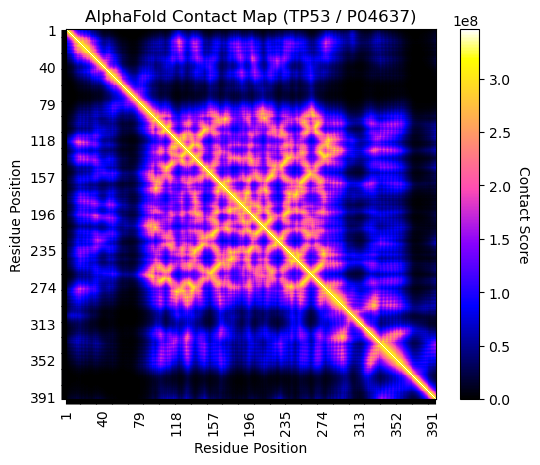

In [127]:
figS6a = cf.plot_contact_map(contact_map=contact_map_ref, 
                            title=f"AlphaFold Contact Map ({target_gene} / {uniprot_id})",  
                            bin_size=1,   
                            pow=4, 
                            agg_func=np.nanmax)
contact_map_ref  = figS6a["data"]["contact_map"]
contact_map_ref_binned = figS6a["data"]["contact_map_binned"]
figS6a['fig'].savefig("manuscript/fig/figS6a.png", **utils.FIG_SAVE_KWARGS)

### Figure 2B

DYPD sensitization map (aligned) +  DYPD AlphaFold contact map (reference sequence).

Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.  
Then plot the contact map and the sensitization map.

In [128]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

100%|██████████| 1/1 [00:00<00:00, 115.88it/s]


Number of top interactions: 578 (8.20% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 9.40x


In [129]:
vep_prot.loc[(vep_prot["site"].isin(top_interactions["site"].head(10)))].groupby("site")["VEP"].mean().sort_values(ascending=False)
# vep_prot.loc[vep_prot["site"]=="NP_009225.1:V1687I"]["VEP"].hist(bins=50)

site
NP_000537.3:R213Q    -3.953045
NP_000537.3:G199V    -4.150334
NP_000537.3:H179Y    -6.292132
NP_000537.3:H179Q    -6.932359
NP_000537.3:R158S    -7.322601
NP_000537.3:D281N    -7.763233
NP_000537.3:R213P    -8.252064
NP_000537.3:D281G   -10.244985
NP_000537.3:D281V   -10.545165
NP_000537.3:D281Y   -10.916056
Name: VEP, dtype: float64

In [130]:
top_interactions.head(20)

,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT
2354,215S>R,NP_000537.3:R213P,2.445649,2.445649,more benign,1,1.563857,R213P,215,S,R,213,R,P
2355,215S>R,NP_000537.3:R213Q,1.092954,1.092954,more benign,1,1.045444,R213Q,215,S,R,213,R,Q
3015,273R>H,NP_000537.3:D281N,0.857769,0.857769,more benign,1,0.926158,D281N,273,R,H,281,D,N
1447,175R>C,NP_000537.3:H179Y,0.846658,0.846658,more benign,1,0.920140,H179Y,175,R,C,179,H,Y
3016,273R>H,NP_000537.3:D281V,0.840008,0.840008,more benign,1,0.916519,D281V,273,R,H,281,D,V
3017,273R>H,NP_000537.3:D281Y,0.821178,0.821178,more benign,1,0.906189,D281Y,273,R,H,281,D,Y
1695,202R>C,NP_000537.3:G199V,0.788605,0.788605,more benign,1,0.888035,G199V,202,R,C,199,G,V
3014,273R>H,NP_000537.3:D281G,0.673420,0.673420,more benign,1,0.820622,D281G,273,R,H,281,D,G
2347,215S>R,NP_000537.3:R158S,0.645741,0.645741,more benign,1,0.803580,R158S,215,S,R,158,R,S
1446,175R>C,NP_000537.3:H179Q,0.610163,0.610163,more benign,1,0.781129,H179Q,175,R,C,179,H,Q


(393, 393)
Adding rectangles


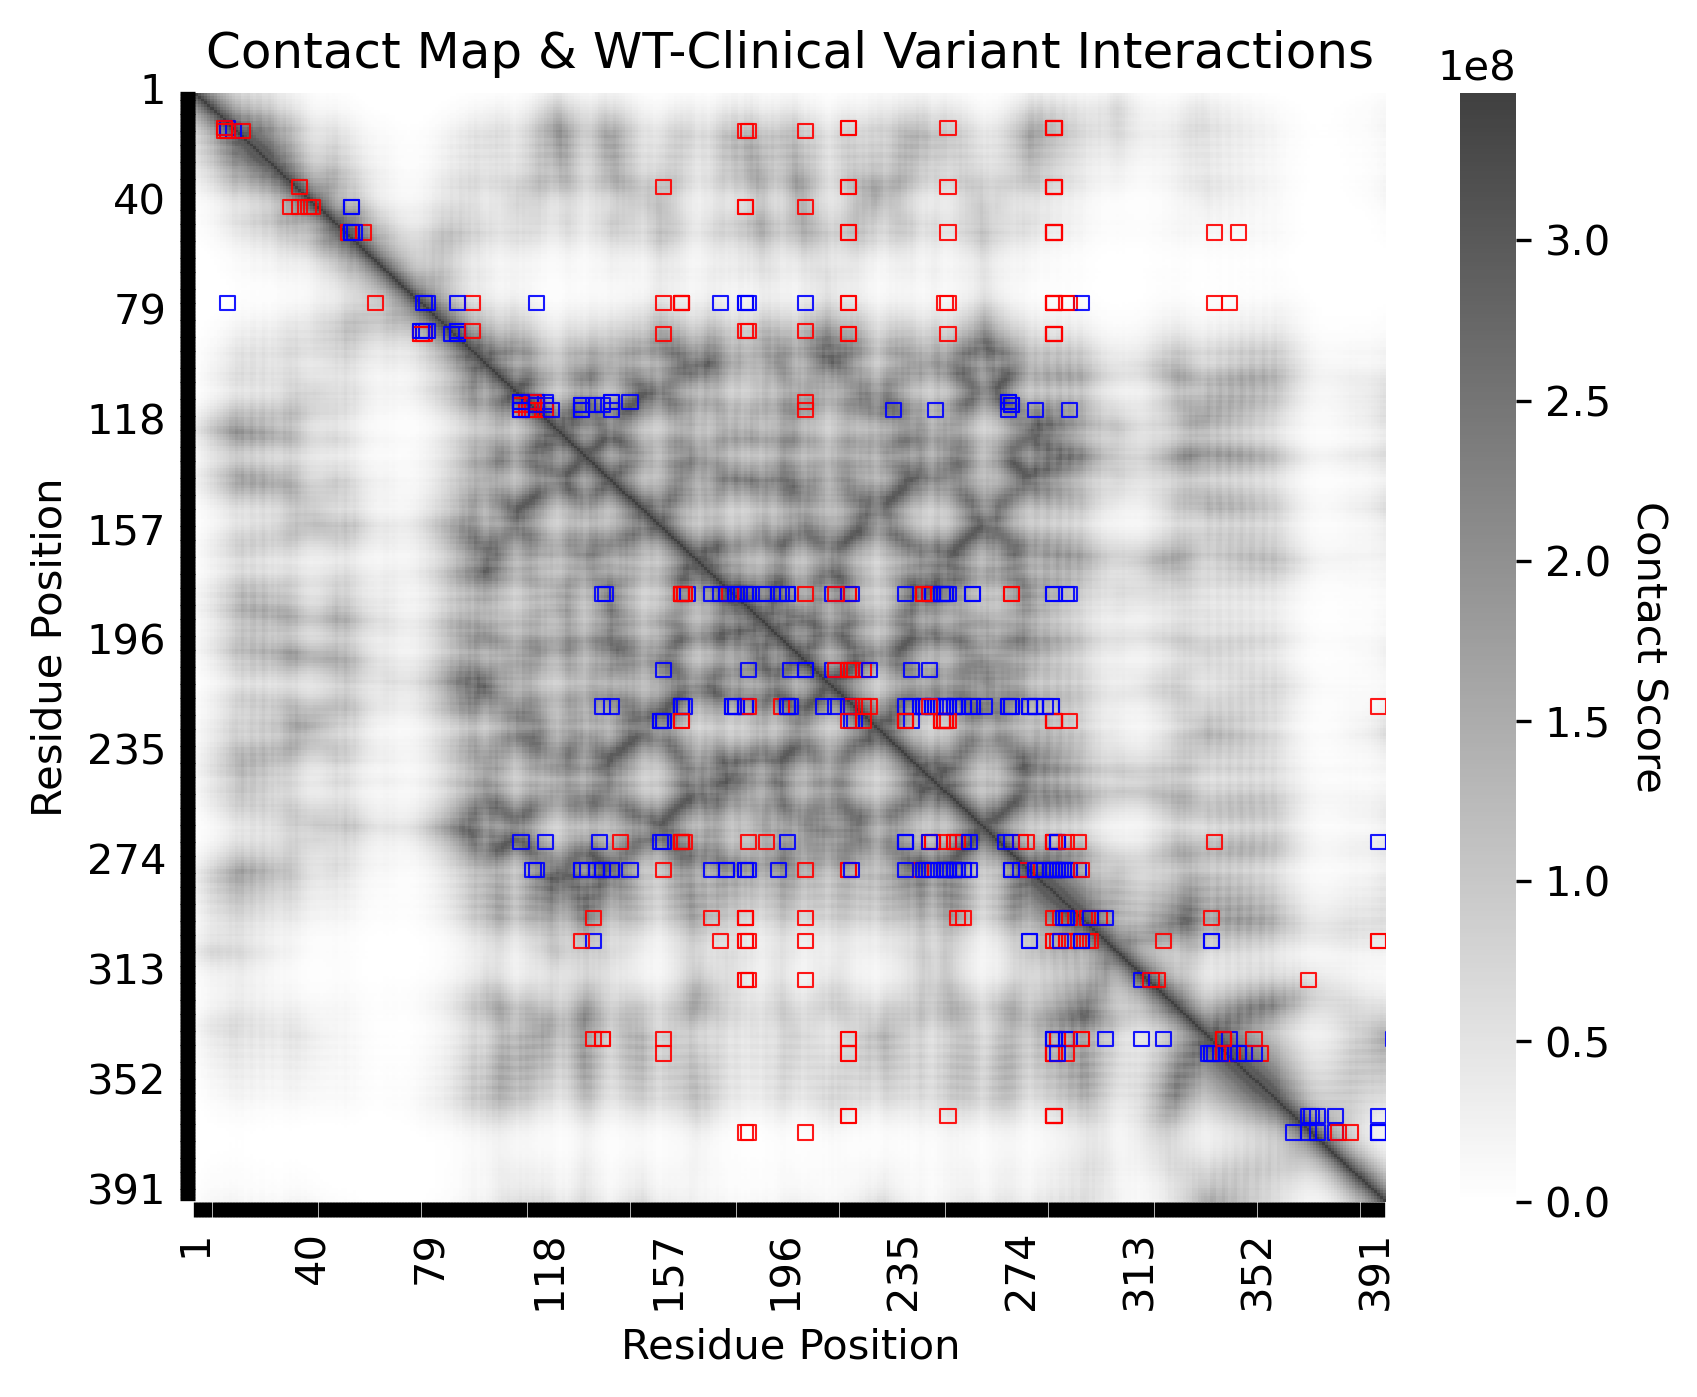

In [131]:
figS6b = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=contact_map_ref_binned,
    outlier_sig=top_interactions, 
    heatmap_alpha=0.75,
    height_width=5,
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=rf"Contact Map & WT-Clinical Variant Interactions",# +"\n"+rf"(Interaction Strength $\geq$ {interaction_threshold})",
    show_plot=(False, True),
    # figsize=(10, 10)
)
figS6b["fig"]["subplot2"].savefig("manuscript/fig/figS6b.png", **utils.FIG_SAVE_KWARGS)

### Figure S6c

Contact enrichment: outlier detection method

In [132]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 112.56it/s]


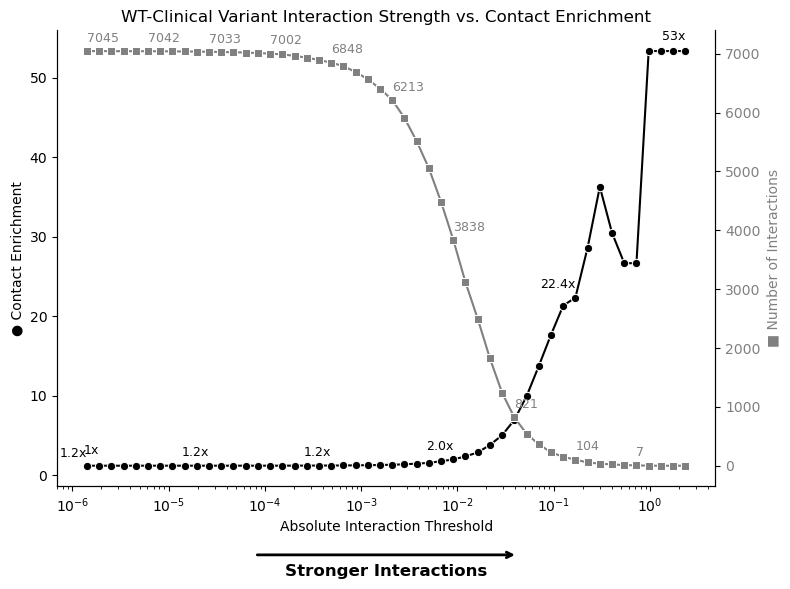

In [133]:
figS6c = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                           figsize=(8, 6),
                                   log_x_axis=True, 
                                   y1_first_label=True,
                                   y1_last_label=True,
                                   y2_first_label=True,
                                   y2_last_label=True, )
figS6c["fig"].savefig("manuscript/fig/figS6c.png", **utils.FIG_SAVE_KWARGS)

### Figure 2E

Mean interaction strength per clinical variant.

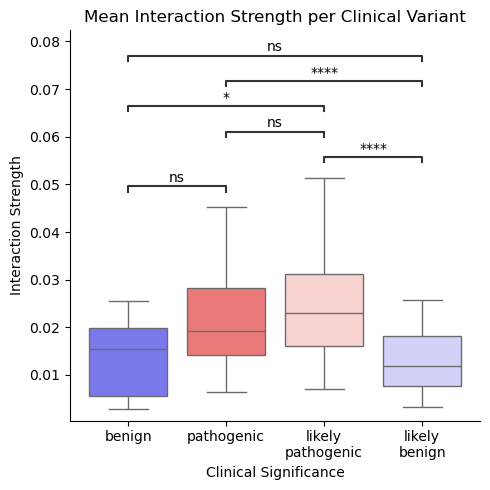

In [134]:
figS6d = ab.plot_clinsig_interaction_strength(
    ridge_df, 
    vep_prot,
    title="Mean Interaction Strength per Clinical Variant",
    xlabel="Clinical Significance",
    ylabel="Interaction Strength", 
    text_format="star",
    figsize=(5, 5),
)
figS6d["fig"].savefig("manuscript/fig/figS6d.png", **utils.FIG_SAVE_KWARGS)

### Figure 2F

Interaction strength vs. Angstroms.

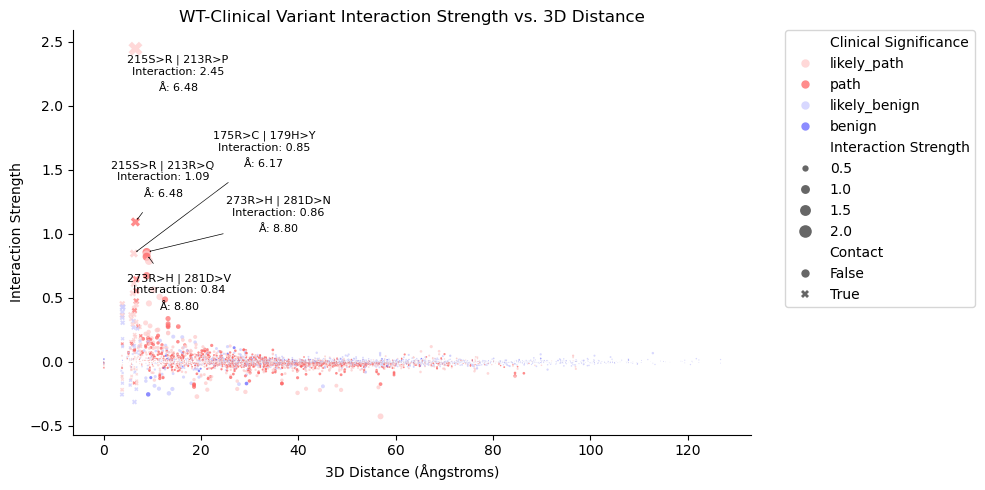

In [135]:
# Use a lambda to pass contact_map_ref as a closure variable, avoiding the error
ridge_df["position_distance"] = (ridge_df["wt_position"] - ridge_df["clinical_position"]).abs()
ridge_df["Angstroms"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_dist_ref), axis=1)
ridge_df["is_contact"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_binary_ref)==1, axis=1) 
ridge_df["clinical_variant_fmt"] = ridge_df["clinical_variant"].apply(
    lambda x: (
        f"{x[1:-1]}{x[0]}>{x[-1]}"
        if isinstance(x, str) and len(x) >= 3 and x[1:-1].isdigit()
        else x
    )
)
ridge_df['protein'] = ridge_df['site'].str.split(":").str[0]
ridge_df = utils.add_hgvsp_id(ridge_df)

fig6e = ab.plot_wt_clinical_interaction_vs_angstroms(ridge_df, vep_prot, N=5)
fig6e["fig"].savefig("manuscript/fig/figS6e.png", **utils.FIG_SAVE_KWARGS)

Check the baseline enrichment of all interactions with the top WT variant.

In [141]:
top_wt_variants = ridge_df.groupby("wt_variant")["interaction_strength"].mean().sort_values(ascending=False)
contact_maps_wt = {k:v for k,v in contact_maps.items() if top_wt_variants.index[0].replace(">","_") in k or k==cf.get_ref_key(contact_maps)}
top_wt_variants.head()

wt_variant
273R>H    0.057969
215S>R    0.055300
175R>C    0.047084
263N>D    0.029662
72P>R     0.026771
Name: interaction_strength, dtype: float64

In [142]:
ridge_enrichment_at_threshold_top1= ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df.loc[(ridge_df["wt_variant"]==top_wt_variants.index.tolist()[0])],
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[0,],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)
ridge_enrichment_at_threshold_top1

100%|██████████| 1/1 [00:00<00:00, 111.78it/s]


,observed_prob,expected_prob,binom_test,enrichment,interaction_threshold,n_interactions
0,0.055556,0.018738,"BinomTestResult(k=9, n=162, alternative='two-s...",2.964927,0,271


### Figure 2G
Personalized contact maps vs. REF contact map. 

In [143]:
#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1 ) 

contact_maps = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True)  

26 PDB files found


100%|██████████| 26/26 [00:00<00:00, 42.92it/s]


<string>:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


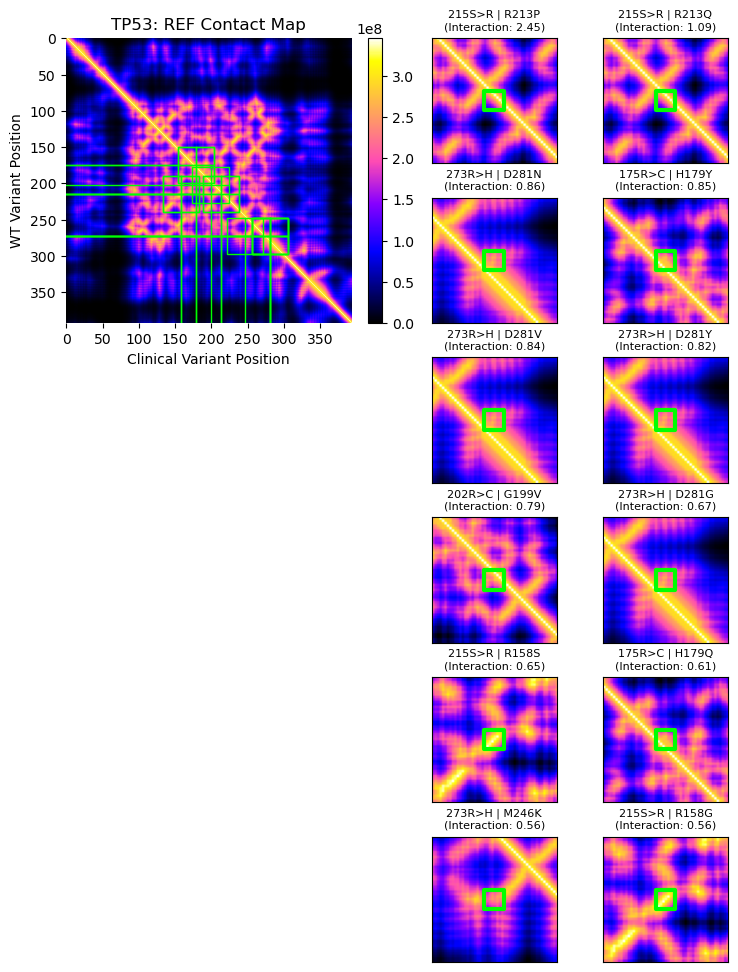

In [146]:
figS6f = cf.plot_contact_map_and_zooms(
    contact_maps_wt,
    ridge_df,
    target_gene, 
    main_plot_above=False,
    max_highlights=12,
    highlight_size=50,
    zoom_nrows = 6,
    zoom_ncols=None,
    zoom_subplot_size = 2,
    main_nrows = 2,
    main_ncols = 2,
    pow=4,
    main_padding=0.25,
    save_path="manuscript/fig/figS6f.png"
)

### Figure 2H

Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

In [147]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:01<00:00, 21.45it/s]


In [148]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

# Get a merged FASTA file
merged_fasta = hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                        tx_ids=[tx_id],
                        save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                        split_subdir="",
                        # force=True,
                        compress=False) 

# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 


Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


...

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 26 haplotypes across 1 tx_ids.


Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Padding contact maps to MSA: 100%|██████████| 26/26 [00:00<00:00, 891.11it/s]


In [149]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7720, 16)
>> haplotype(s): 26
>> cohort(s): 3
>> cohort_sample(s): 3878
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
EAS    5
AFR    5
SAS    4
EUR    4
AMR    4
MID    1
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 88.46%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000269305:10V>I,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SAS,0.000992,1,SAS,1.0
1,"ENSP00000269305:11E>Q,72P>R",0.000000,0.0,0.0,0.001379,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,EAS,0.001379,1,EAS,2.0
2,ENSP00000269305:215S>R,0.000000,0.0,0.0,0.000000,0.000753,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,EUR,0.000753,1,EUR,1.0
3,ENSP00000269305:220Y>H,0.000418,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,0.000418,1,AFR,1.0
4,ENSP00000269305:263N>D,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SAS,0.000992,1,SAS,1.0


In [150]:
pop_contact_maps = cf.compute_population_specific_contact_maps(
    contact_maps=contact_maps,
    contact_maps_binary=contact_maps_binary,
    freq_df=freq_df, 
    superpopulation_specific_only=False,
    exclude_ref_from_weights=True,
    weight_binary_maps=True,
)
specific_maps = pop_contact_maps["specific_maps"]
specific_diff_maps = pop_contact_maps["specific_diff_maps"]
specific_binary_diff_maps = pop_contact_maps["specific_binary_diff_maps"]
specific_binary_diff_figs = pop_contact_maps["specific_binary_diff_figs"]

100%|██████████| 8/8 [00:00<00:00,  8.86it/s]


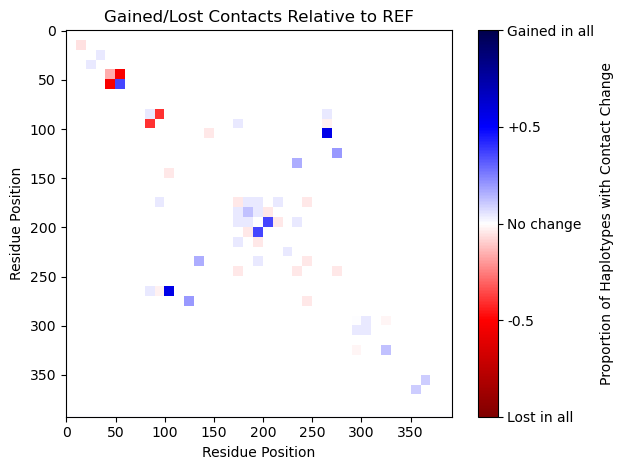

In [155]:
figS6g = cf.plot_contact_map_diff(contact_maps_binary,  
                                bin_size=10,
                                weights=None,
                                show_plot=True,
                                verbose=False)
figS6g["fig"].savefig("manuscript/fig/figS6g.png", **utils.FIG_SAVE_KWARGS)

### Figure 2I

In [156]:
%%capture

fig_superop_diff = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True,
    show_plot=False
)

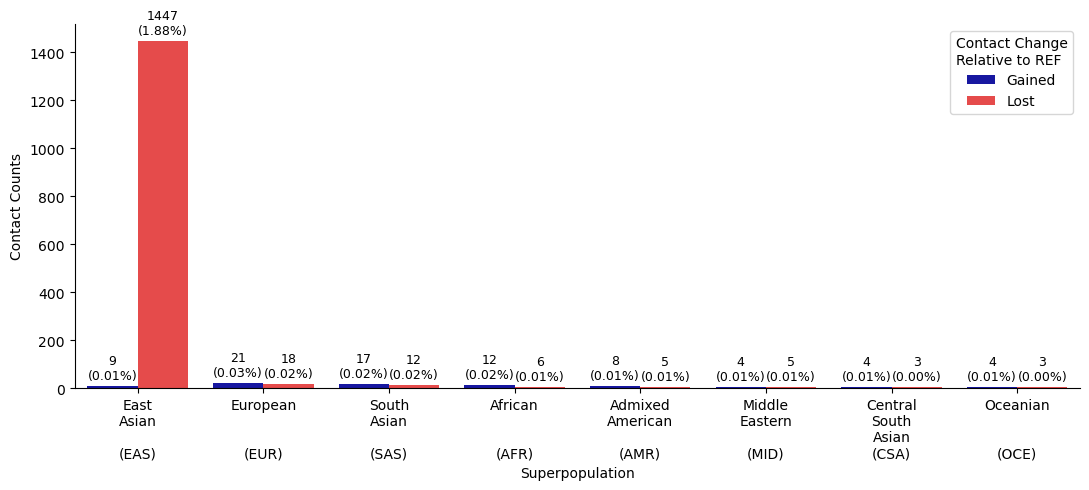

In [158]:
figS6h = cf.plot_contact_map_diff_barplot_grouped(
    bar_df=fig_superop_diff['data'],
    group_by="superpopulation", 
      figsize=(11, 5),
    )
figS6h['fig'].savefig("manuscript/fig/figS6h.png", **utils.FIG_SAVE_KWARGS)
